# D4: FAQ Search — сравнение 6 подходов (v2)

**Гипотеза D4**: Если заменить keyword matching в FAQ на LLM context stuffing, embedding semantic search или гибридные подходы, то:
- Покрытие (coverage) вырастет с ~43% до >90%
- Точность подбора врача/специализации вырастет
- При допустимом росте latency и стоимости

**Подходы:**
- **A (Keyword)**: keyword matching (`kb_stub.py`) + regex + embedding (`DoctorNameMatcher`)
- **B (LLM)**: context stuffing — clinic_info + doctors → `qwen/qwen3.5-35b-a3b` via OpenRouter
- **C1 (Embedding RoSBERTa)**: semantic search через `ai-forever/ru-en-RoSBERTa` (MPS)
- **C2 (Embedding bge-m3)**: semantic search через `BAAI/bge-m3` (MPS)
- **D (Keyword → LLM)**: hybrid — keyword first, fallback на LLM
- **E (Embedding → LLM)**: hybrid — embedding (bge-m3) first, fallback на LLM

**Метрики:**
1. **Coverage** — доля запросов с корректным поведением (ответ для answerable, fallback для not_found)
2. **Answer accuracy** — доля ответов с ожидаемыми ключевыми фразами
3. **Doctor match** — точность определения врача по фамилии
4. **Specialization accuracy** — точность определения специализации
5. **Suggest booking accuracy** — точность предложения записи
6. **Latency** (ms) и **Token cost** (только для LLM)

**Модели:**
| Компонент | Модель | Параметры |
|-----------|--------|-----------|
| LLM | `qwen/qwen3.5-35b-a3b` | temperature=0.1, via OpenRouter |
| Embedding C1 | `ai-forever/ru-en-RoSBERTa` | device=MPS (Apple Silicon) |
| Embedding C2 | `BAAI/bge-m3` | device=MPS (Apple Silicon) |

**Тестовый набор:** 50 golden samples из `data/d4_faq_golden_samples.yaml`

In [1]:
# ============================================================================
# 1. SETUP
# ============================================================================
import sys
import time
import json
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from dataclasses import dataclass, field

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
STUDY_ROOT = Path(".").resolve()
AI_CORE_ROOT = STUDY_ROOT.parent / "ai-core"
PROFILE_DIR = AI_CORE_ROOT / "apps" / "agent-llm" / "core" / "config" / "profile"
DATA_DIR = STUDY_ROOT / "data"
OUTPUT_DIR = STUDY_ROOT / "outputs"

# Seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Verify paths
assert PROFILE_DIR.exists(), f"Profile dir not found: {PROFILE_DIR}"
assert (DATA_DIR / "d4_faq_golden_samples.yaml").exists(), "Golden samples not found"

print(f"Study root: {STUDY_ROOT}")
print(f"Profile dir: {PROFILE_DIR}")
print(f"Python: {sys.version}")

Study root: /Users/kazdoraw/developer/med-agent/study
Profile dir: /Users/kazdoraw/developer/med-agent/ai-core/apps/agent-llm/core/config/profile
Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 08:03:38) [Clang 14.0.6 ]


In [2]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================

# 2.1 Golden samples
with open(DATA_DIR / "d4_faq_golden_samples.yaml", "r", encoding="utf-8") as f:
    golden_data = yaml.safe_load(f)
samples = golden_data["samples"]
df_samples = pd.DataFrame(samples)

# 2.2 Clinic info
with open(PROFILE_DIR / "clinic_info.yaml", "r", encoding="utf-8") as f:
    clinic_info = yaml.safe_load(f)

# 2.3 Doctors
with open(PROFILE_DIR / "doctors.yaml", "r", encoding="utf-8") as f:
    doctors_data = yaml.safe_load(f)
doctors_list = doctors_data.get("doctors", [])

print(f"Golden samples: {len(samples)}")
print(f"Doctors: {len(doctors_list)}")
print(f"\nCategory distribution:")
print(df_samples["category"].value_counts().to_string())
print(f"\nDifficulty distribution:")
print(df_samples["difficulty"].value_counts().to_string())

Golden samples: 50
Doctors: 22

Category distribution:
category
clinic_info       24
specialization    12
doctor_search      9
not_found          5

Difficulty distribution:
difficulty
hard      21
easy      15
medium    14


## 3. Baseline A: Keyword Matching (текущий kb_stub.py)

Воспроизводим логику из `kb_stub.py` + `specialists.py` без импорта production кода.

In [3]:
# ============================================================================
# 3. BASELINE A: Keyword Matching (reproduces kb_stub.py + specialists.py)
# ============================================================================

@dataclass
class FAQResult:
    """Унифицированный результат любого подхода FAQ."""
    answer: str = ""
    found_doctor: Optional[str] = None
    specialization: Optional[str] = None
    suggest_booking: bool = False
    is_fallback: bool = False
    latency_ms: float = 0.0
    tokens_used: int = 0


# --- 3.1 Воспроизведение kb_stub.py keyword search ---

KEYWORD_RULES = {
    "children": {
        "keywords": ["дет", "ребен", "ребён", "малыш"],
        "response": "Да, мы принимаем детей! Семейная клиника «Клевер» — семейная клиника. "
                    "Для комфорта детей используем закись азота + кислород — снятие страха перед лечением.",
    },
    "address": {
        "keywords": ["адрес", "где", "находит", "как добрать", "приехать", "доехать", "расположен"],
        "response": "Адрес: Ульяновск, ул. Рябикова, 56",
    },
    "hours": {
        # "когда" удалён — вызывал false positive ("щелкает челюсть когда жую" → hours)
        "keywords": ["время", "часы", "работа", "график", "выходн", "воскресен", "суббот", "открыт", "прийти", "до скольки"],
        "response": "Режим работы: ежедневно с 08:00 до 20:00",
    },
    "contacts": {
        "keywords": ["телефон", "позвон", "связ", "контакт", "номер"],
        "response": "Телефон: +7 (842) 231-45-55, +7 (927) 831-45-55",
    },
    "financing": {
        "keywords": ["рассрочк", "кредит", "оплат", "частями"],
        "response": "Да, доступна беспроцентная рассрочка на 6, 10 месяцев.",
    },
    "sedation": {
        "keywords": ["седац", "наркоз", "сон", "боль", "страх", "боюсь"],
        "response": "Да, мы проводим лечение во сне (седация). Также доступна закись азота для снятия страха.",
    },
    "documents": {
        "keywords": ["документ", "договор", "согласи", "бумаг"],
        "response": "Для приёма необходимы: договор на оказание стоматологических услуг, "
                    "согласие на обработку персональных данных, ИДС, анкета здоровья.",
    },
    "licenses": {
        "keywords": ["лицензи", "разрешен", "сертификат"],
        "response": "Да, у клиники есть выписка из реестра лицензий (2024-02-22).",
    },
    "supervisory": {
        "keywords": ["контрол", "надзор", "провер", "кто следит", "жалоб"],
        "response": "Надзорные органы: Территориальный орган Росздравнадзора по Ульяновской области, "
                    "Управление Роспотребнадзора по Ульяновской области, Министерство здравоохранения РФ.",
    },
    "about": {
        "keywords": ["о клиник", "расскаж", "что за клиник", "о вашей"],
        "response": "Семейная клиника «Клевер» — современное и уютное медицинское учреждение, "
                    "специализирующееся на предоставлении высококачественных стоматологических услуг "
                    "для всей семьи.",
    },
}

FALLBACK_ANSWER = "К сожалению, не нашёл информацию по вашему вопросу. Могу помочь с записью к врачу?"


def keyword_search_clinic(query: str) -> Optional[str]:
    """Воспроизведение _search_clinic_info() из kb_stub.py."""
    query_lower = query.lower()
    answers = []
    for _cat, rule in KEYWORD_RULES.items():
        if any(kw in query_lower for kw in rule["keywords"]):
            answers.append(rule["response"])
    return "\n".join(answers) if answers else None


# --- 3.2 Воспроизведение normalize_specialization() ---

SPECIALIZATION_KEYWORDS = {
    "Хирургическая стоматология": [
        "хирург", "удален", "удали", "имплант", "мудрост", "флюс",
        "припухл", "шатает", "свищ", "периостит",
    ],
    "Терапевтическая стоматология": [
        "терапевт", "кариес", "пульпит", "пломб", "реставрац",
        "камен", "налет", "чистк", "кровоточ", "десн",
        "запах", "периодонт", "откол", "скол",
    ],
    "Ортодонтия": [
        "ортодонт", "прикус", "брекет", "кривые", "элайнер",
        "скученн", "щель", "щелкает", "неровн",
    ],
    "Ортопедическая стоматология": [
        "ортопед", "коронк", "протез", "винир", "мост",
        "стираемост", "жевать", "нечем",
    ],
    "Детская стоматология": [
        "детск", "ребен", "ребён", "малыш", "молочн",
    ],
}


def keyword_normalize_specialization(query: str) -> Optional[str]:
    """Воспроизведение normalize_specialization() из specialists.py."""
    query_lower = query.lower()
    for spec, keywords in SPECIALIZATION_KEYWORDS.items():
        if any(kw in query_lower for kw in keywords):
            return spec
    return None


# --- 3.3 Извлечение фамилии с поддержкой русских склонений ---

KNOWN_SURNAMES = [d["full_name"].split()[0].lower() for d in doctors_list]
SURNAME_TO_DOCTOR = {
    d["full_name"].split()[0].lower(): d for d in doctors_list
}


def _build_surname_forms(surname: str) -> List[str]:
    """Генерация типичных форм склонения русских фамилий."""
    forms = [surname]
    if surname.endswith("ская"):
        stem = surname[:-4]
        forms.extend([stem + "ской", stem + "скую"])
    elif surname.endswith("ая"):
        stem = surname[:-2]
        forms.extend([stem + "ой", stem + "ую"])
    elif surname.endswith("ва") or surname.endswith("на"):
        stem = surname[:-1]
        forms.extend([stem + "ой", stem + "у", stem + "ы"])
    elif surname.endswith("а"):
        stem = surname[:-1]
        forms.extend([stem + "е", stem + "у", stem + "ой", stem + "ы"])
    else:
        forms.extend([surname + "у", surname + "а", surname + "ом", surname + "е"])
    return forms


SURNAME_FORMS: Dict[str, str] = {}
for _sn in KNOWN_SURNAMES:
    for _form in _build_surname_forms(_sn):
        SURNAME_FORMS[_form] = _sn


def keyword_extract_surname(text: str) -> Optional[Dict[str, Any]]:
    """Извлечение фамилии с поддержкой русских склонений."""
    text_lower = text.lower()
    for form, base_surname in SURNAME_FORMS.items():
        if form in text_lower:
            return SURNAME_TO_DOCTOR[base_surname]
    return None


# --- 3.4 Ключевые слова для предложения записи ---

BOOKING_KEYWORDS = ["запис", "прием", "врач", "хочу", "работает", "есть", "принимает"]


def keyword_suggest_booking(query: str) -> bool:
    """Воспроизведение логики suggest_booking из faq.py."""
    query_lower = query.lower()
    return any(w in query_lower for w in BOOKING_KEYWORDS)


# --- 3.5 Запуск Baseline A ---

def run_baseline_a(query: str) -> FAQResult:
    """Полный пайплайн Baseline A для одного запроса."""
    t0 = time.perf_counter()
    
    # 1. Поиск по KB
    clinic_answer = keyword_search_clinic(query)
    
    # 2. Специализация
    spec = keyword_normalize_specialization(query)
    
    # 3. Поиск фамилии
    doctor = keyword_extract_surname(query)
    
    # 4. Предложение записи
    suggest = keyword_suggest_booking(query)
    
    latency = (time.perf_counter() - t0) * 1000
    
    # Формирование ответа
    if doctor:
        d = doctor
        answer = f"Да, у нас работает {d['full_name']} ({d['specialization']}, стаж {d['experience_years']} лет)."
        return FAQResult(
            answer=answer,
            found_doctor=d["full_name"],
            specialization=d["specialization"],
            suggest_booking=suggest,
            is_fallback=False,
            latency_ms=latency,
        )
    
    if clinic_answer:
        return FAQResult(
            answer=clinic_answer,
            specialization=spec,
            suggest_booking=suggest,
            is_fallback=False,
            latency_ms=latency,
        )
    
    if spec:
        return FAQResult(
            answer=f"Рекомендую обратиться к специалисту: {spec}.",
            specialization=spec,
            suggest_booking=suggest,
            is_fallback=False,
            latency_ms=latency,
        )
    
    return FAQResult(
        answer=FALLBACK_ANSWER,
        suggest_booking=suggest,
        is_fallback=True,
        latency_ms=latency,
    )


# Запуск на всех сэмплах
results_a = []
for s in samples:
    result = run_baseline_a(s["query"])
    results_a.append(result)

print(f"Baseline A завершён: {len(results_a)} запросов")
print(f"Средняя задержка: {np.mean([r.latency_ms for r in results_a]):.2f} мс")
print(f"Доля fallback: {sum(r.is_fallback for r in results_a) / len(results_a):.1%}")

Baseline A завершён: 50 запросов
Средняя задержка: 0.01 мс
Доля fallback: 4.0%


## 4. Proposed B: LLM Context Stuffing (Together AI)

Отправляем clinic_info.yaml + doctors.yaml как контекст в LLM.
Structured output через JSON extraction из ответа.

In [4]:
# ============================================================================
# 4. PROPOSED B: LLM Context Stuffing (OpenRouter)
# ============================================================================

import requests as http_requests
from dotenv import load_dotenv
import os

load_dotenv()

# --- 4.1 Config ---
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_API_URL = "https://openrouter.ai/api/v1/chat/completions"
LLM_MODEL = "qwen/qwen3.5-35b-a3b"
LLM_TEMPERATURE = 0.1
LLM_MAX_TOKENS = 16384

print(f"API key: {'установлен (' + OPENROUTER_API_KEY[:12] + '...)' if OPENROUTER_API_KEY else 'НЕ УСТАНОВЛЕН'}")
print(f"Модель: {LLM_MODEL}")
print(f"Провайдер: OpenRouter")

API key: установлен (sk-or-v1-293...)
Модель: qwen/qwen3.5-35b-a3b
Провайдер: OpenRouter


In [5]:
# --- 4.2 Build context strings (cached) ---

def build_clinic_context(clinic_data: dict) -> str:
    """Serialize clinic_info.yaml to compact text for LLM prompt."""
    c = clinic_data.get("clinic", {})
    parts = [
        f"Клиника: {c.get('name', '')}",
        f"Адрес: {c.get('location', {}).get('city', '')}, {c.get('location', {}).get('address', '')}",
        f"Телефоны: {', '.join(c.get('contacts', {}).get('phones', []))}",
        f"Email: {', '.join(c.get('contacts', {}).get('emails', []))}",
        f"Режим работы: {c.get('working_hours', {}).get('schedule_text', '')}",
        f"Описание: {c.get('summary', {}).get('description', '').strip()}",
    ]
    # Sedation
    sed = c.get("patient_comfort_and_safety", {}).get("sedation", {})
    if sed.get("dental_sleep"):
        parts.append("Седация: лечение во сне доступно")
    nit = sed.get("nitrous_oxide", {})
    if nit.get("available"):
        parts.append(f"Закись азота: {nit.get('mixture', '')} — {nit.get('purpose', '')}")
    # Financing
    fin = c.get("financing", {}).get("installments", {})
    if fin.get("available"):
        months = ", ".join(map(str, fin.get("months", [])))
        parts.append(f"Рассрочка: {fin.get('type', '')} на {months} месяцев")
    # Documents
    docs = c.get("documents", {}).get("items", [])
    if docs:
        doc_names = [d["name"] for d in docs]
        parts.append(f"Документы: {'; '.join(doc_names)}")
    # Licenses
    lics = c.get("licenses", {}).get("items", [])
    if lics:
        lic_names = [l["name"] for l in lics]
        parts.append(f"Лицензии: {'; '.join(lic_names)}")
    # Supervisory
    sup = c.get("supervisory_bodies", {}).get("items", [])
    if sup:
        sup_names = [s["name"] for s in sup]
        parts.append(f"Надзорные органы: {'; '.join(sup_names)}")
    # Website
    pages = c.get("website", {}).get("pages", {})
    if pages:
        parts.append(f"Сайт: {c.get('website', {}).get('base_url', '')}")
        page_list = [f"{k}: {v}" for k, v in pages.items()]
        parts.append(f"Страницы: {'; '.join(page_list)}")
    return "\n".join(parts)


def build_doctors_context(doctors: list) -> str:
    """Serialize doctors.yaml to compact text for LLM prompt."""
    lines = []
    for d in doctors:
        complaints = ", ".join(d.get("patient_complaints", [])[:5])
        cases = ", ".join(d.get("clinical_cases", [])[:5])
        lines.append(
            f"- {d['full_name']} | {d['specialization']} | стаж {d['experience_years']} лет | "
            f"случаи: {cases} | жалобы: {complaints}"
        )
    return "\n".join(lines)


CLINIC_CONTEXT = build_clinic_context(clinic_info)
DOCTORS_CONTEXT = build_doctors_context(doctors_list)

# Token estimate (~4 chars per token for Russian)
clinic_tokens_est = len(CLINIC_CONTEXT) // 4
doctors_tokens_est = len(DOCTORS_CONTEXT) // 4
print(f"Clinic context: {len(CLINIC_CONTEXT)} chars ≈ {clinic_tokens_est} tokens")
print(f"Doctors context: {len(DOCTORS_CONTEXT)} chars ≈ {doctors_tokens_est} tokens")
print(f"Total context: ≈ {clinic_tokens_est + doctors_tokens_est} tokens")

Clinic context: 1545 chars ≈ 386 tokens
Doctors context: 7892 chars ≈ 1973 tokens
Total context: ≈ 2359 tokens


In [6]:
# --- 4.3 LLM System Prompt ---

FAQ_SYSTEM_PROMPT = """Ты — ассистент стоматологической клиники. Отвечай на вопросы пациентов, используя ТОЛЬКО предоставленные данные.

ДАННЫЕ КЛИНИКИ:
{clinic_context}

ВРАЧИ КЛИНИКИ:
{doctors_context}

ЗАДАЧА: На основе вопроса пациента верни JSON:
{{
  "answer": "Ответ пациенту на русском. Если информации нет — честно скажи.",
  "found_doctor": "ФИО врача если вопрос о конкретном враче, иначе null",
  "specialization": "Специализация если определена из жалобы/запроса, иначе null",
  "suggest_booking": true/false,
  "has_answer": true/false
}}

ПРАВИЛА:
1. Отвечай ТОЛЬКО на основе предоставленных данных. Не выдумывай.
2. Если врач упомянут по фамилии — найди в списке врачей и верни found_doctor с ТОЧНЫМ ФИО.
3. Если пациент описывает жалобу — определи специализацию по clinical_cases/patient_complaints врачей.
4. suggest_booking=true если пациент хочет записаться или ему нужен конкретный врач/услуга.
5. has_answer=false если в данных нет информации для ответа.
6. Верни ТОЛЬКО JSON, без пояснений."""

# Format once (context is static)
FAQ_SYSTEM_FORMATTED = FAQ_SYSTEM_PROMPT.format(
    clinic_context=CLINIC_CONTEXT,
    doctors_context=DOCTORS_CONTEXT,
)

system_tokens_est = len(FAQ_SYSTEM_FORMATTED) // 4
print(f"System prompt: {len(FAQ_SYSTEM_FORMATTED)} chars ≈ {system_tokens_est} tokens")

System prompt: 10392 chars ≈ 2598 tokens


In [7]:
# --- 4.4 LLM Call function (OpenRouter) ---

def call_faq_llm(query: str) -> FAQResult:
    """Вызов OpenRouter LLM с context stuffing для FAQ."""
    if not OPENROUTER_API_KEY:
        return FAQResult(answer="[LLM недоступен]", is_fallback=True)
    
    t0 = time.perf_counter()
    
    try:
        response = http_requests.post(
            OPENROUTER_API_URL,
            headers={
                "Authorization": f"Bearer {OPENROUTER_API_KEY}",
                "Content-Type": "application/json",
            },
            json={
                "model": LLM_MODEL,
                "messages": [
                    {"role": "system", "content": FAQ_SYSTEM_FORMATTED},
                    {"role": "user", "content": query},
                ],
                "temperature": LLM_TEMPERATURE,
                "max_tokens": LLM_MAX_TOKENS,
            },
            timeout=60,
        )
        latency = (time.perf_counter() - t0) * 1000
        
        if response.status_code != 200:
            return FAQResult(
                answer=f"[Ошибка API {response.status_code}]",
                is_fallback=True,
                latency_ms=latency,
            )
        
        data = response.json()
        content = data["choices"][0]["message"]["content"]
        tokens = data.get("usage", {}).get("total_tokens", 0)
        
        # Defensive JSON parsing: извлечение JSON из ответа LLM
        parsed = _parse_llm_json(content)
        
        if parsed:
            return FAQResult(
                answer=parsed.get("answer", "") or "",
                found_doctor=parsed.get("found_doctor"),
                specialization=parsed.get("specialization"),
                suggest_booking=bool(parsed.get("suggest_booking", False)),
                is_fallback=not parsed.get("has_answer", True),
                latency_ms=latency,
                tokens_used=tokens,
            )
        
        # Не удалось распарсить JSON → fallback с raw content
        return FAQResult(
            answer=content,
            is_fallback=True,
            latency_ms=latency,
            tokens_used=tokens,
        )
        
    except Exception as e:
        latency = (time.perf_counter() - t0) * 1000
        return FAQResult(
            answer=f"[Ошибка: {e}]",
            is_fallback=True,
            latency_ms=latency,
        )


def _parse_llm_json(content: str) -> Optional[dict]:
    """Defensive парсинг JSON из ответа LLM. Возвращает dict или None."""
    if not content or not isinstance(content, str):
        return None
    
    # Стратегия 1: простой JSON объект без вложенных {}
    json_match = re.search(r'\{[^{}]*\}', content, re.DOTALL)
    if not json_match:
        # Стратегия 2: JSON с вложенными объектами
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
    
    if not json_match:
        return None
    
    try:
        parsed = json.loads(json_match.group())
        if not isinstance(parsed, dict):
            return None
        return parsed
    except (json.JSONDecodeError, TypeError):
        return None


# Тест одного запроса
if OPENROUTER_API_KEY:
    test_result = call_faq_llm("Где находится клиника?")
    print(f"Тест: ответ='{test_result.answer[:80]}...'")
    print(f"  задержка={test_result.latency_ms:.0f}мс, токены={test_result.tokens_used}")
else:
    print("⚠️ OPENROUTER_API_KEY не установлен — LLM подход будет пропущен")

Тест: ответ='Клиника находится по адресу: Ульяновск, ул. Рябикова, 56....'
  задержка=7889мс, токены=3949


In [9]:
# --- 4.5 Запуск Proposed B на всех сэмплах ---

results_b = []
HAS_LLM = bool(OPENROUTER_API_KEY)

if HAS_LLM:
    for i, s in enumerate(samples):
        result = call_faq_llm(s["query"])
        results_b.append(result)
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(samples)}] средняя задержка={np.mean([r.latency_ms for r in results_b]):.0f}мс")
        time.sleep(0.3)  # Rate limit
    
    print(f"\nProposed B (LLM) завершён: {len(results_b)} запросов")
    print(f"Средняя задержка: {np.mean([r.latency_ms for r in results_b]):.0f} мс")
    print(f"Среднее токенов: {np.mean([r.tokens_used for r in results_b]):.0f}")
    print(f"Доля fallback: {sum(r.is_fallback for r in results_b) / len(results_b):.1%}")
else:
    print("⚠️ Пропуск LLM подхода — нет API ключа")
    results_b = [FAQResult(answer="[пропущено]", is_fallback=True) for _ in samples]

  [10/50] средняя задержка=27473мс
  [20/50] средняя задержка=21002мс
  [30/50] средняя задержка=19927мс
  [40/50] средняя задержка=21147мс
  [50/50] средняя задержка=32113мс

Proposed B (LLM) завершён: 50 запросов
Средняя задержка: 32113 мс
Среднее токенов: 6834
Доля fallback: 16.0%


## 5. Proposed C: Embedding Semantic Search

Два encoder для сравнения:
- **C1**: `ai-forever/ru-en-RoSBERTa` (1024-dim, русский)
- **C2**: `BAAI/bge-m3` (1024-dim, мультиязычный)

Чанкуем clinic_info и doctors в семантические фрагменты, кодируем на MPS (Apple Silicon), ищем по cosine similarity.

In [10]:
# ============================================================================
# 5. PROPOSED C: Embedding Semantic Search (два encoder для сравнения)
# ============================================================================

try:
    from sentence_transformers import SentenceTransformer
    HAS_ENCODER = True
except ImportError:
    HAS_ENCODER = False
    print("sentence-transformers не установлен — embedding подходы будут пропущены")

# --- Конфигурация двух моделей ---
ENCODER_CONFIGS = {
    "c1": {
        "name": "ai-forever/ru-en-RoSBERTa",
        "device": "mps",
        "similarity_threshold": 0.4,
        "doctor_name_threshold": 0.8,
        "label": "C1: Emb (RoSBERTa)",
    },
    "c2": {
        "name": "BAAI/bge-m3",
        "device": "mps",
        "similarity_threshold": 0.4,
        "doctor_name_threshold": 0.8,
        "label": "C2: Emb (bge-m3)",
    },
}

# Обратная совместимость: глобальные переменные для отчётов
ENCODER_MODEL_1 = ENCODER_CONFIGS["c1"]["name"]
ENCODER_MODEL_2 = ENCODER_CONFIGS["c2"]["name"]
ENCODER_DEVICE = "mps"

print(f"Encoder C1: {ENCODER_MODEL_1}")
print(f"Encoder C2: {ENCODER_MODEL_2}")
print(f"Device: {ENCODER_DEVICE}")


# --- 5.1 Построение семантических чанков из clinic_info + doctors ---

def build_clinic_chunks(clinic_data: dict) -> List[Dict[str, str]]:
    """Конвертация clinic_info.yaml в поисковые текстовые чанки с метаданными."""
    c = clinic_data.get("clinic", {})
    chunks = []
    
    # Адрес
    loc = c.get("location", {})
    if loc:
        chunks.append({
            "text": f"Клиника {c.get('name', '')} находится по адресу: {loc.get('city', '')}, {loc.get('address', '')}",
            "category": "address",
        })
    
    # Часы работы
    hours = c.get("working_hours", {})
    if hours:
        chunks.append({
            "text": f"Режим работы клиники: {hours.get('schedule_text', '')} ({hours.get('days', '')})",
            "category": "hours",
        })
    
    # Контакты
    contacts = c.get("contacts", {})
    phones = contacts.get("phones", [])
    emails = contacts.get("emails", [])
    if phones or emails:
        text = f"Контакты клиники: телефоны {', '.join(phones)}"
        if emails:
            text += f", email: {', '.join(emails)}"
        chunks.append({"text": text, "category": "contacts"})
    
    # О клинике
    summary = c.get("summary", {}).get("description", "")
    if summary:
        chunks.append({
            "text": f"О клинике: {c.get('name', '')} — {summary.strip()}",
            "category": "summary",
        })
    
    # Седация
    sed = c.get("patient_comfort_and_safety", {}).get("sedation", {})
    if sed.get("dental_sleep"):
        nit = sed.get("nitrous_oxide", {})
        text = "Лечение во сне (седация) доступно."
        if nit.get("available"):
            text += f" Также доступна {nit.get('mixture', 'закись азота')} — {nit.get('purpose', '')}."
        chunks.append({"text": text, "category": "sedation"})
    
    # Рассрочка
    fin = c.get("financing", {}).get("installments", {})
    if fin.get("available"):
        months = ", ".join(map(str, fin.get("months", [])))
        chunks.append({
            "text": f"Доступна {fin.get('type', 'рассрочка')} на {months} месяцев.",
            "category": "financing",
        })
    
    # Дети
    chunks.append({
        "text": f"{c.get('name', 'Клиника')} — семейная клиника, принимает пациентов всех возрастов, включая детей.",
        "category": "children",
    })
    
    # Документы
    docs = c.get("documents", {}).get("items", [])
    if docs:
        doc_names = "; ".join([d["name"] for d in docs])
        chunks.append({
            "text": f"Документы для пациентов: {doc_names}",
            "category": "documents",
        })
    
    # Лицензии
    lics = c.get("licenses", {}).get("items", [])
    if lics:
        lic_names = "; ".join([l["name"] for l in lics])
        chunks.append({
            "text": f"Лицензии: {lic_names}",
            "category": "licenses",
        })
    
    # Надзорные органы
    sup = c.get("supervisory_bodies", {}).get("items", [])
    if sup:
        sup_names = "; ".join([s["name"] for s in sup])
        chunks.append({
            "text": f"Надзорные органы: {sup_names}",
            "category": "supervisory",
        })
    
    return chunks


def build_doctor_chunks(doctors: list) -> List[Dict[str, str]]:
    """Конвертация doctors.yaml в поисковые чанки (1 чанк на врача)."""
    chunks = []
    for d in doctors:
        complaints = "; ".join(d.get("patient_complaints", []))
        cases = "; ".join(d.get("clinical_cases", []))
        text = (
            f"{d['full_name']}, {d['specialization']}, стаж {d['experience_years']} лет. "
            f"Клинические случаи: {cases}. Жалобы пациентов: {complaints}."
        )
        chunks.append({
            "text": text,
            "doctor": d["full_name"],
            "specialization": d["specialization"],
            "category": "doctor",
        })
    return chunks


# Построение чанков (общие для обоих encoder)
clinic_chunks = build_clinic_chunks(clinic_info)
doctor_chunks = build_doctor_chunks(doctors_list)
all_chunks = clinic_chunks + doctor_chunks

# Фамилии врачей (общие для обоих encoder)
doctor_surnames = [d["full_name"].split()[0] for d in doctors_list]
doctor_surname_map = {d["full_name"].split()[0]: d for d in doctors_list}

print(f"Чанки клиники: {len(clinic_chunks)}")
print(f"Чанки врачей: {len(doctor_chunks)}")
print(f"Всего чанков: {len(all_chunks)}")
print(f"Фамилий: {len(doctor_surnames)}")

Encoder C1: ai-forever/ru-en-RoSBERTa
Encoder C2: BAAI/bge-m3
Device: mps
Чанки клиники: 10
Чанки врачей: 22
Всего чанков: 32
Фамилий: 22


In [11]:
# --- 5.2 Загрузка encoder и индексация чанков ---

# Хранилище: encoder → (model, chunk_embeddings, surname_embeddings)
encoders = {}

if HAS_ENCODER:
    chunk_texts = [c["text"] for c in all_chunks]
    
    for key, cfg in ENCODER_CONFIGS.items():
        print(f"\n{'='*60}")
        print(f"Загрузка {cfg['label']}: {cfg['name']} (device={cfg['device']})")
        print(f"{'='*60}")
        
        model = SentenceTransformer(cfg["name"], device=cfg["device"])
        
        # Кодирование чанков
        t0 = time.perf_counter()
        chunk_embs = model.encode(chunk_texts, show_progress_bar=False, normalize_embeddings=True)
        encode_time = (time.perf_counter() - t0) * 1000
        
        # Кодирование фамилий врачей
        surname_embs = model.encode(doctor_surnames, show_progress_bar=False, normalize_embeddings=True)
        
        encoders[key] = {
            "model": model,
            "chunk_embeddings": chunk_embs,
            "surname_embeddings": surname_embs,
            "config": cfg,
        }
        
        print(f"  Закодировано {len(chunk_texts)} чанков + {len(doctor_surnames)} фамилий за {encode_time:.0f}мс")
        print(f"  Размерность: {chunk_embs.shape[1]}")
    
    print(f"\n✅ Загружено encoder: {len(encoders)}")
else:
    print("⚠️ sentence-transformers не установлен")


Загрузка C1: Emb (RoSBERTa): ai-forever/ru-en-RoSBERTa (device=mps)


Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Закодировано 32 чанков + 22 фамилий за 1569мс
  Размерность: 1024

Загрузка C2: Emb (bge-m3): BAAI/bge-m3 (device=mps)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

  Закодировано 32 чанков + 22 фамилий за 1857мс
  Размерность: 1024

✅ Загружено encoder: 2


In [12]:
# --- 5.3 Параметризованная функция embedding search ---

def embedding_search(query: str, encoder_key: str, top_k: int = 3) -> FAQResult:
    """Семантический поиск по чанкам clinic_info + doctors.
    
    Args:
        query: запрос пользователя
        encoder_key: ключ encoder ("c1" или "c2")
        top_k: количество лучших чанков
    """
    if not HAS_ENCODER or encoder_key not in encoders:
        return FAQResult(answer="[encoder недоступен]", is_fallback=True)
    
    enc = encoders[encoder_key]
    model = enc["model"]
    chunk_embs = enc["chunk_embeddings"]
    surname_embs = enc["surname_embeddings"]
    cfg = enc["config"]
    
    t0 = time.perf_counter()
    
    # Кодирование запроса
    query_emb = model.encode([query], normalize_embeddings=True)
    
    # 1. Поиск фамилии (word-level matching)
    words = query.split()
    found_doctor = None
    if len(words) <= 15:
        word_embs = model.encode(words, normalize_embeddings=True)
        sims = word_embs @ surname_embs.T  # (n_words, n_surnames)
        max_sim = sims.max()
        if max_sim >= cfg["doctor_name_threshold"]:
            best_word_idx, best_surname_idx = np.unravel_index(sims.argmax(), sims.shape)
            matched_surname = doctor_surnames[best_surname_idx]
            found_doctor = doctor_surname_map[matched_surname]
    
    # 2. Поиск по чанкам (cosine similarity)
    similarities = (query_emb @ chunk_embs.T).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    
    latency = (time.perf_counter() - t0) * 1000
    
    # Сборка результата из лучших чанков
    best_chunks = []
    specialization = None
    suggest_booking = False
    
    for idx in top_indices:
        sim = similarities[idx]
        if sim < cfg["similarity_threshold"]:
            break
        chunk = all_chunks[idx]
        best_chunks.append((chunk, sim))
        
        # Извлечение специализации из doctor-чанков
        if chunk.get("category") == "doctor" and not specialization:
            specialization = chunk.get("specialization")
            suggest_booking = True
    
    # Если найден врач по фамилии — приоритет
    if found_doctor:
        answer = (
            f"Да, у нас работает {found_doctor['full_name']} "
            f"({found_doctor['specialization']}, стаж {found_doctor['experience_years']} лет)."
        )
        return FAQResult(
            answer=answer,
            found_doctor=found_doctor["full_name"],
            specialization=found_doctor["specialization"],
            suggest_booking=True,
            is_fallback=False,
            latency_ms=latency,
        )
    
    if not best_chunks:
        return FAQResult(
            answer=FALLBACK_ANSWER,
            is_fallback=True,
            latency_ms=latency,
        )
    
    # Формирование ответа из лучших чанков
    answer_parts = []
    for chunk, sim in best_chunks:
        if chunk.get("category") == "doctor":
            doc_name = chunk.get("doctor", "")
            doc_spec = chunk.get("specialization", "")
            answer_parts.append(f"Рекомендуем: {doc_name} ({doc_spec})")
        else:
            answer_parts.append(chunk["text"])
    
    return FAQResult(
        answer="\n".join(answer_parts),
        specialization=specialization,
        suggest_booking=suggest_booking,
        is_fallback=False,
        latency_ms=latency,
    )


# Фабричные функции для удобства вызова
def embedding_search_c1(query: str) -> FAQResult:
    """C1: Embedding search с ai-forever/ru-en-RoSBERTa."""
    return embedding_search(query, "c1")

def embedding_search_c2(query: str) -> FAQResult:
    """C2: Embedding search с BAAI/bge-m3."""
    return embedding_search(query, "c2")


# Тест обоих encoder
if HAS_ENCODER:
    test_query = "Где находится клиника?"
    for key, enc in encoders.items():
        test = embedding_search(test_query, key)
        cfg = enc["config"]
        print(f"\n{cfg['label']}: '{test.answer[:80]}...'")
        print(f"  model={cfg['name']}, latency={test.latency_ms:.1f}мс, fallback={test.is_fallback}")


C1: Emb (RoSBERTa): 'К сожалению, не нашёл информацию по вашему вопросу. Могу помочь с записью к врач...'
  model=ai-forever/ru-en-RoSBERTa, latency=586.0мс, fallback=True

C2: Emb (bge-m3): 'Рекомендуем: Абраамян Андела Корюновна (Терапевтическая стоматология)
Режим рабо...'
  model=BAAI/bge-m3, latency=813.8мс, fallback=False


In [13]:
# --- 5.4 Запуск Embedding подходов C1 и C2 на всех сэмплах ---

results_c1 = []
results_c2 = []

if HAS_ENCODER:
    # C1: ai-forever/ru-en-RoSBERTa
    for s in samples:
        results_c1.append(embedding_search_c1(s["query"]))
    
    print(f"C1 (RoSBERTa) завершён: {len(results_c1)} запросов")
    print(f"  Средняя задержка: {np.mean([r.latency_ms for r in results_c1]):.1f} мс")
    print(f"  Доля fallback: {sum(r.is_fallback for r in results_c1) / len(results_c1):.1%}")
    
    # C2: BAAI/bge-m3
    for s in samples:
        results_c2.append(embedding_search_c2(s["query"]))
    
    print(f"\nC2 (bge-m3) завершён: {len(results_c2)} запросов")
    print(f"  Средняя задержка: {np.mean([r.latency_ms for r in results_c2]):.1f} мс")
    print(f"  Доля fallback: {sum(r.is_fallback for r in results_c2) / len(results_c2):.1%}")
else:
    print("⚠️ Пропуск embedding подходов — sentence-transformers не установлен")
    results_c1 = [FAQResult(answer="[пропущено]", is_fallback=True) for _ in samples]
    results_c2 = [FAQResult(answer="[пропущено]", is_fallback=True) for _ in samples]

C1 (RoSBERTa) завершён: 50 запросов
  Средняя задержка: 60.5 мс
  Доля fallback: 44.0%

C2 (bge-m3) завершён: 50 запросов
  Средняя задержка: 60.9 мс
  Доля fallback: 24.0%


## 5.5 Гибридные подходы D и E

- **D (Keyword → LLM):** Keyword first, при fallback — LLM context stuffing
- **E (Embedding → LLM):** Embedding (bge-m3) first, при fallback — LLM context stuffing

Оба гибрида используют LLM как второй слой. Разница — в первом слое: D использует быстрый keyword, E использует семантический embedding.

In [14]:
# --- 5.5 Гибридные подходы D и E ---

def hybrid_keyword_llm(query: str) -> FAQResult:
    """D: Keyword → LLM fallback.
    
    Keyword отвечает мгновенно на прямые совпадения.
    При fallback — LLM с полным контекстом clinic+doctors.
    """
    result_a = run_baseline_a(query)
    if not result_a.is_fallback:
        return result_a  # Keyword уверенно ответил
    
    # Fallback на LLM
    result_b = call_faq_llm(query)
    # Суммируем latency обоих слоёв
    result_b.latency_ms += result_a.latency_ms
    return result_b


def hybrid_embedding_llm(query: str) -> FAQResult:
    """E: Embedding (bge-m3) → LLM fallback.
    
    Embedding search через bge-m3 (локально, ~50-150мс).
    При fallback — LLM с полным контекстом.
    """
    result_c2 = embedding_search_c2(query)
    if not result_c2.is_fallback:
        return result_c2  # Embedding нашёл ответ
    
    # Fallback на LLM
    result_b = call_faq_llm(query)
    # Суммируем latency обоих слоёв
    result_b.latency_ms += result_c2.latency_ms
    return result_b


print("Гибридные подходы определены:")
print("  D: hybrid_keyword_llm() — Keyword → LLM")
print("  E: hybrid_embedding_llm() — Embedding (bge-m3) → LLM")

Гибридные подходы определены:
  D: hybrid_keyword_llm() — Keyword → LLM
  E: hybrid_embedding_llm() — Embedding (bge-m3) → LLM


In [15]:
# --- 5.6 Запуск гибридных подходов D и E на всех сэмплах ---

# D: Keyword → LLM
results_d = []
if HAS_LLM:
    for i, s in enumerate(samples):
        results_d.append(hybrid_keyword_llm(s["query"]))
        if (i + 1) % 10 == 0:
            print(f"  D [{i+1}/{len(samples)}] средняя задержка={np.mean([r.latency_ms for r in results_d]):.0f}мс")
        time.sleep(0.2)  # Rate limit для LLM запросов
    
    fallback_count_d = sum(r.is_fallback for r in results_a)
    print(f"\nD (Key→LLM) завершён: {len(results_d)} запросов")
    print(f"  Keyword обработал: {len(results_d) - fallback_count_d}/{len(results_d)}")
    print(f"  Fallback на LLM: {fallback_count_d}/{len(results_d)}")
    print(f"  Средняя задержка: {np.mean([r.latency_ms for r in results_d]):.0f} мс")
    print(f"  Доля fallback: {sum(r.is_fallback for r in results_d) / len(results_d):.1%}")
else:
    print("⚠️ Пропуск D (Key→LLM) — нет API ключа")
    results_d = [FAQResult(answer="[пропущено]", is_fallback=True) for _ in samples]

# E: Embedding (bge-m3) → LLM
results_e = []
if HAS_LLM and HAS_ENCODER:
    for i, s in enumerate(samples):
        results_e.append(hybrid_embedding_llm(s["query"]))
        if (i + 1) % 10 == 0:
            print(f"  E [{i+1}/{len(samples)}] средняя задержка={np.mean([r.latency_ms for r in results_e]):.0f}мс")
        time.sleep(0.2)  # Rate limit для LLM запросов
    
    fallback_count_e = sum(r.is_fallback for r in results_c2)
    print(f"\nE (Emb→LLM) завершён: {len(results_e)} запросов")
    print(f"  Embedding обработал: {len(results_e) - fallback_count_e}/{len(results_e)}")
    print(f"  Fallback на LLM: {fallback_count_e}/{len(results_e)}")
    print(f"  Средняя задержка: {np.mean([r.latency_ms for r in results_e]):.0f} мс")
    print(f"  Доля fallback: {sum(r.is_fallback for r in results_e) / len(results_e):.1%}")
else:
    print("⚠️ Пропуск E (Emb→LLM) — нет API ключа или encoder")
    results_e = [FAQResult(answer="[пропущено]", is_fallback=True) for _ in samples]

  D [10/50] средняя задержка=0мс
  D [20/50] средняя задержка=0мс
  D [30/50] средняя задержка=0мс
  D [40/50] средняя задержка=0мс
  D [50/50] средняя задержка=542мс

D (Key→LLM) завершён: 50 запросов
  Keyword обработал: 48/50
  Fallback на LLM: 2/50
  Средняя задержка: 542 мс
  Доля fallback: 4.0%
  E [10/50] средняя задержка=4475мс
  E [20/50] средняя задержка=3875мс
  E [30/50] средняя задержка=3375мс
  E [40/50] средняя задержка=3109мс
  E [50/50] средняя задержка=3369мс

E (Emb→LLM) завершён: 50 запросов
  Embedding обработал: 38/50
  Fallback на LLM: 12/50
  Средняя задержка: 3369 мс
  Доля fallback: 4.0%


## 6. Evaluation — метрики по всем подходам

In [16]:
# ============================================================================
# 6. ОЦЕНКА РЕЗУЛЬТАТОВ
# ============================================================================

def evaluate_results(
    samples: list,
    results: List[FAQResult],
    approach_name: str,
) -> pd.DataFrame:
    """Оценить результаты FAQ по golden samples. Возвращает DataFrame по каждому сэмплу."""
    rows = []
    for s, r in zip(samples, results):
        category = s.get("category", "")
        is_not_found = category == "not_found"
        
        # 6.1 Покрытие: корректное поведение
        # not_found: fallback = правильно; остальные: не fallback = правильно
        if is_not_found:
            covered = r.is_fallback
        else:
            covered = not r.is_fallback
        
        # 6.2 Точность ответа: ожидаемые фразы присутствуют в ответе
        expected_phrases = s.get("expected_answer_contains", [])
        if expected_phrases:
            matches = sum(
                1 for phrase in expected_phrases
                if phrase.lower() in r.answer.lower()
            )
            answer_accuracy = matches / len(expected_phrases)
        else:
            if is_not_found:
                # not_found без ожидаемых фраз: fallback=1.0, ответ=0.75
                answer_accuracy = 1.0 if r.is_fallback else 0.75
            else:
                # Нет ожидаемых фраз → accuracy=1 если fallback, 0.5 для неожиданных ответов
                answer_accuracy = 1.0 if r.is_fallback else 0.5
        
        # 6.3 Совпадение врача
        expected_doctor = s.get("expected_doctor")
        if expected_doctor:
            if r.found_doctor:
                expected_surname = expected_doctor.split()[0].lower()
                found_surname = r.found_doctor.split()[0].lower()
                doctor_match = expected_surname == found_surname
            else:
                doctor_match = False
        else:
            doctor_match = r.found_doctor is None  # True negative
        
        # 6.4 Точность специализации
        expected_spec = s.get("expected_specialization")
        if expected_spec:
            if r.specialization:
                spec_match = expected_spec.lower() in r.specialization.lower()
            else:
                spec_match = False
        else:
            spec_match = r.specialization is None  # True negative
        
        # 6.5 Предложение записи
        expected_booking = s.get("expected_suggest_booking", False)
        booking_match = r.suggest_booking == expected_booking
        
        rows.append({
            "id": s["id"],
            "запрос": s["query"],
            "категория": s["category"],
            "подкатегория": s.get("subcategory", ""),
            "сложность": s.get("difficulty", ""),
            "подход": approach_name,
            "покрытие": covered,
            "точность_ответа": answer_accuracy,
            "врач_совпал": doctor_match,
            "спец_совпала": spec_match,
            "запись_совпала": booking_match,
            "задержка_мс": r.latency_ms,
            "токены": r.tokens_used,
            "превью_ответа": r.answer[:100],
            "найден_врач": r.found_doctor,
            "найдена_спец": r.specialization,
        })
    
    return pd.DataFrame(rows)


# Оценка всех 6 подходов
df_eval_a  = evaluate_results(samples, results_a,  "A: Keyword")
df_eval_b  = evaluate_results(samples, results_b,  "B: LLM")
df_eval_c1 = evaluate_results(samples, results_c1, "C1: Emb (RoSBERTa)")
df_eval_c2 = evaluate_results(samples, results_c2, "C2: Emb (bge-m3)")
df_eval_d  = evaluate_results(samples, results_d,  "D: Key→LLM")
df_eval_e  = evaluate_results(samples, results_e,  "E: Emb→LLM")

df_eval = pd.concat(
    [df_eval_a, df_eval_b, df_eval_c1, df_eval_c2, df_eval_d, df_eval_e],
    ignore_index=True,
)

n_approaches = df_eval["подход"].nunique()
print(f"Оценка завершена: {len(df_eval)} строк ({len(samples)} сэмплов × {n_approaches} подходов)")
print(f"  Подходы: {', '.join(df_eval['подход'].unique())}")
print(f"  Метрика покрытия: корректное поведение (fallback для not_found = True)")
print(f"  Метрика точности: not_found fallback = 1.0, not_found ответ = 0.75")

Оценка завершена: 300 строк (50 сэмплов × 6 подходов)
  Подходы: A: Keyword, B: LLM, C1: Emb (RoSBERTa), C2: Emb (bge-m3), D: Key→LLM, E: Emb→LLM
  Метрика покрытия: корректное поведение (fallback для not_found = True)
  Метрика точности: not_found fallback = 1.0, not_found ответ = 0.75


In [17]:
# ============================================================================
# 6.2 Сводная таблица метрик
# ============================================================================

# Глобальный список подходов и цветов — используется во всех визуализациях
APPROACH_NAMES = [
    "A: Keyword",
    "B: LLM",
    "C1: Emb (RoSBERTa)",
    "C2: Emb (bge-m3)",
    "D: Key→LLM",
    "E: Emb→LLM",
]
APPROACH_COLORS = [
    "#5B9BD5",  # A — синий
    "#ED7D31",  # B — оранжевый
    "#70AD47",  # C1 — зелёный
    "#2E7D32",  # C2 — тёмно-зелёный
    "#7B1FA2",  # D — фиолетовый
    "#C62828",  # E — красный
]


def compute_aggregate_metrics(df: pd.DataFrame, approach: str) -> dict:
    """Вычислить агрегированные метрики для одного подхода."""
    sub = df[df["подход"] == approach]
    n = len(sub)
    
    # Считаем doctor/spec метрики только где есть ожидаемое значение
    doc_ids = [s["id"] for s in samples if s.get("expected_doctor")]
    spec_ids = [s["id"] for s in samples if s.get("expected_specialization")]
    doc_expected = sub[sub["id"].isin(doc_ids)]
    spec_expected = sub[sub["id"].isin(spec_ids)]
    
    return {
        "Подход": approach,
        "Покрытие": f"{sub['покрытие'].mean():.1%}",
        "Точность ответа": f"{sub['точность_ответа'].mean():.1%}",
        "Врач (precision)": f"{doc_expected['врач_совпал'].mean():.1%}" if len(doc_expected) > 0 else "—",
        "Специализация": f"{spec_expected['спец_совпала'].mean():.1%}" if len(spec_expected) > 0 else "—",
        "Предложение записи": f"{sub['запись_совпала'].mean():.1%}",
        "Задержка (мс)": f"{sub['задержка_мс'].mean():.1f}",
        "Токены (сред.)": f"{sub['токены'].mean():.0f}" if sub['токены'].sum() > 0 else "0",
        "n": n,
    }


metrics_summary = pd.DataFrame([
    compute_aggregate_metrics(df_eval, a) for a in APPROACH_NAMES
])

print("=" * 90)
print("СВОДКА: D4 Сравнение подходов FAQ Search (6 подходов)")
print(f"  LLM: {LLM_MODEL}")
print(f"  Embedding C1: {ENCODER_MODEL_1}")
print(f"  Embedding C2: {ENCODER_MODEL_2}")
print(f"  Samples: {len(samples)}")
print("=" * 90)
display(metrics_summary.set_index("Подход"))

СВОДКА: D4 Сравнение подходов FAQ Search (6 подходов)
  LLM: qwen/qwen3.5-35b-a3b
  Embedding C1: ai-forever/ru-en-RoSBERTa
  Embedding C2: BAAI/bge-m3
  Samples: 50


,Покрытие,Точность ответа,Врач (precision),Специализация,Предложение записи,Задержка (мс),Токены (сред.),n
Подход,,,,,,,,
A: Keyword,94.0%,95.5%,100.0%,95.5%,50.0%,0.0,0,50
B: LLM,90.0%,89.5%,100.0%,95.5%,74.0%,32112.7,6834,50
C1: Emb (RoSBERTa),58.0%,47.0%,88.9%,45.5%,58.0%,60.5,0,50
C2: Emb (bge-m3),74.0%,58.5%,77.8%,72.7%,62.0%,60.9,0,50
D: Key→LLM,94.0%,95.5%,100.0%,95.5%,54.0%,542.3,195,50
E: Emb→LLM,94.0%,77.5%,88.9%,81.8%,58.0%,3369.3,1117,50


## 7. Визуализации

### 7.1 Сравнение подходов по ключевым метрикам

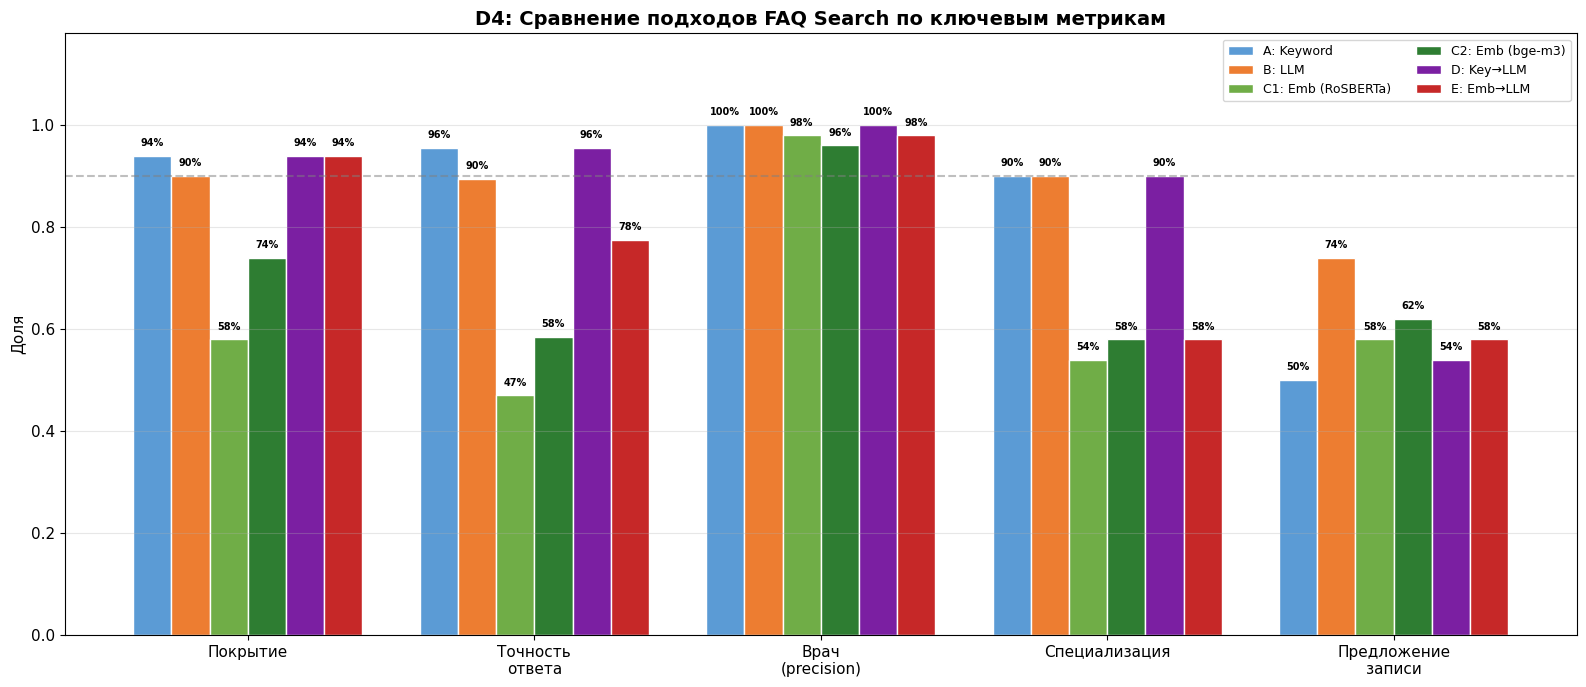

Сохранено: outputs/figures/d4_metrics_comparison.png


In [18]:
# ============================================================================
# 7.1 Bar chart: ключевые метрики по подходам (6 подходов)
# ============================================================================

plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = "white"

METRIC_COLS = ["покрытие", "точность_ответа", "врач_совпал", "спец_совпала", "запись_совпала"]
METRIC_LABELS = ["Покрытие", "Точность\nответа", "Врач\n(precision)", "Специализация", "Предложение\nзаписи"]

# Вычисляем средние значения для каждого подхода
metric_values = {}
for approach in APPROACH_NAMES:
    sub = df_eval[df_eval["подход"] == approach]
    metric_values[approach] = [sub[col].mean() for col in METRIC_COLS]

n_approaches = len(APPROACH_NAMES)
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(METRIC_LABELS))
bar_width = 0.8 / n_approaches  # Авто-масштаб ширины баров

for i, (approach, color) in enumerate(zip(APPROACH_NAMES, APPROACH_COLORS)):
    vals = metric_values[approach]
    bars = ax.bar(x + i * bar_width, vals, bar_width, label=approach, color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f"{val:.0%}", ha="center", va="bottom", fontsize=7, fontweight="bold",
        )

ax.set_ylabel("Доля")
ax.set_title("D4: Сравнение подходов FAQ Search по ключевым метрикам", fontsize=14, fontweight="bold")
ax.set_xticks(x + bar_width * (n_approaches - 1) / 2)
ax.set_xticklabels(METRIC_LABELS)
ax.set_ylim(0, 1.18)
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.axhline(y=0.9, color="gray", linestyle="--", alpha=0.5)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "d4_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: outputs/figures/d4_metrics_comparison.png")

### 7.2 Покрытие по категориям запросов

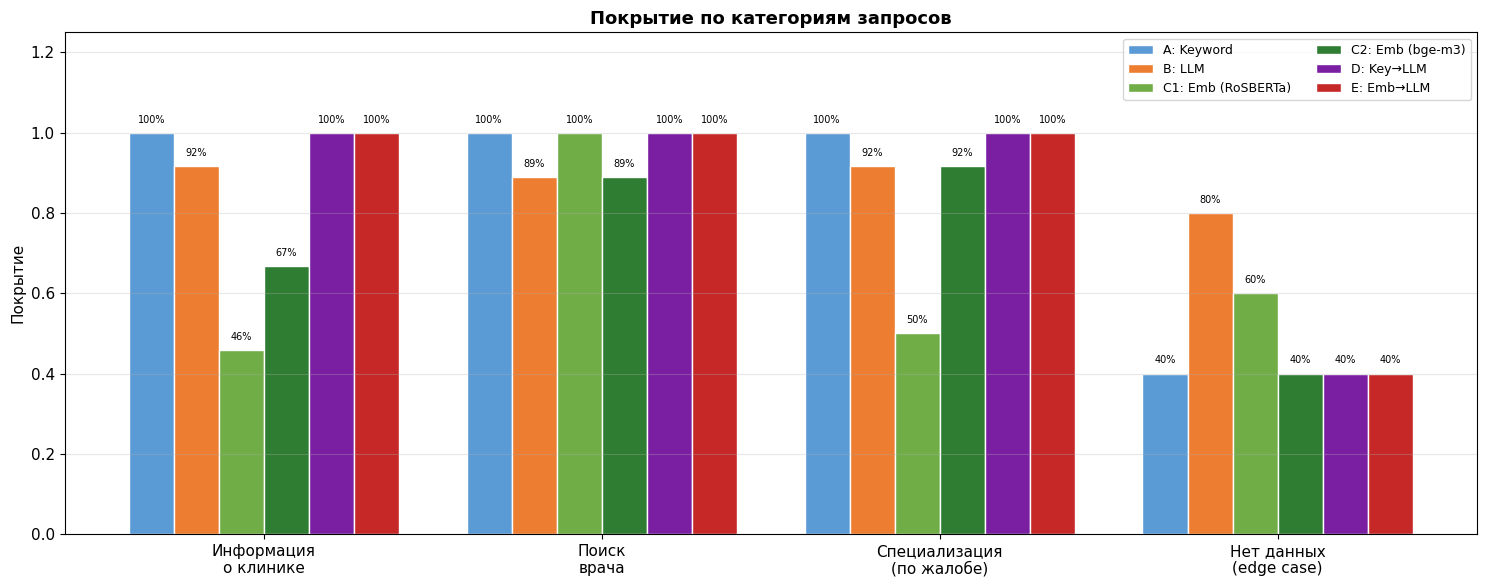

Сохранено: outputs/figures/d4_coverage_by_category.png


In [19]:
# ============================================================================
# 7.2 Покрытие по категориям запросов (6 подходов)
# ============================================================================

CATEGORY_LABELS = {
    "clinic_info": "Информация\nо клинике",
    "doctor_search": "Поиск\nврача",
    "specialization": "Специализация\n(по жалобе)",
    "not_found": "Нет данных\n(edge case)",
}

categories = list(CATEGORY_LABELS.keys())
n_approaches = len(APPROACH_NAMES)

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(categories))
bar_width = 0.8 / n_approaches

for i, (approach, color) in enumerate(zip(APPROACH_NAMES, APPROACH_COLORS)):
    vals = []
    for cat in categories:
        sub = df_eval[(df_eval["подход"] == approach) & (df_eval["категория"] == cat)]
        vals.append(sub["покрытие"].mean() if len(sub) > 0 else 0)
    bars = ax.bar(x + i * bar_width, vals, bar_width, label=approach, color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", va="bottom", fontsize=7,
            )

ax.set_ylabel("Покрытие")
ax.set_title("Покрытие по категориям запросов", fontsize=13, fontweight="bold")
ax.set_xticks(x + bar_width * (n_approaches - 1) / 2)
ax.set_xticklabels([CATEGORY_LABELS[c] for c in categories])
ax.set_ylim(0, 1.25)
ax.legend(fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "d4_coverage_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: outputs/figures/d4_coverage_by_category.png")

### 7.3 Точность по сложности запросов (easy / medium / hard)

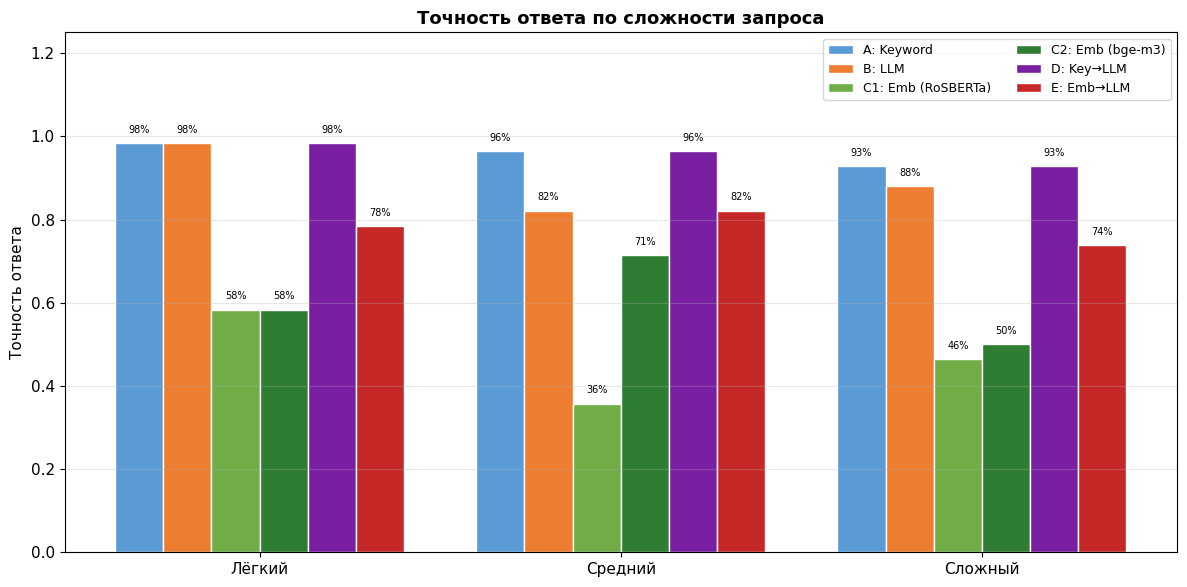

Сохранено: outputs/figures/d4_accuracy_by_difficulty.png


In [20]:
# ============================================================================
# 7.3 Точность ответа по сложности запросов (6 подходов)
# ============================================================================

DIFFICULTY_ORDER = ["easy", "medium", "hard"]
DIFFICULTY_LABELS = {"easy": "Лёгкий", "medium": "Средний", "hard": "Сложный"}
n_approaches = len(APPROACH_NAMES)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(DIFFICULTY_ORDER))
bar_width = 0.8 / n_approaches

for i, (approach, color) in enumerate(zip(APPROACH_NAMES, APPROACH_COLORS)):
    vals = []
    for diff in DIFFICULTY_ORDER:
        sub = df_eval[(df_eval["подход"] == approach) & (df_eval["сложность"] == diff)]
        vals.append(sub["точность_ответа"].mean() if len(sub) > 0 else 0)
    bars = ax.bar(x + i * bar_width, vals, bar_width, label=approach, color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.0%}", ha="center", va="bottom", fontsize=7,
        )

ax.set_ylabel("Точность ответа")
ax.set_title("Точность ответа по сложности запроса", fontsize=13, fontweight="bold")
ax.set_xticks(x + bar_width * (n_approaches - 1) / 2)
ax.set_xticklabels([DIFFICULTY_LABELS[d] for d in DIFFICULTY_ORDER])
ax.set_ylim(0, 1.25)
ax.legend(fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "d4_accuracy_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: outputs/figures/d4_accuracy_by_difficulty.png")

### 7.4 Сравнение задержки (latency)

/var/folders/6w/j5zxb2n50dj_hrb7t96x08bh0000gn/T/ipykernel_56617/433307104.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(latency_data, labels=short_labels, patch_artist=True, showmeans=True)


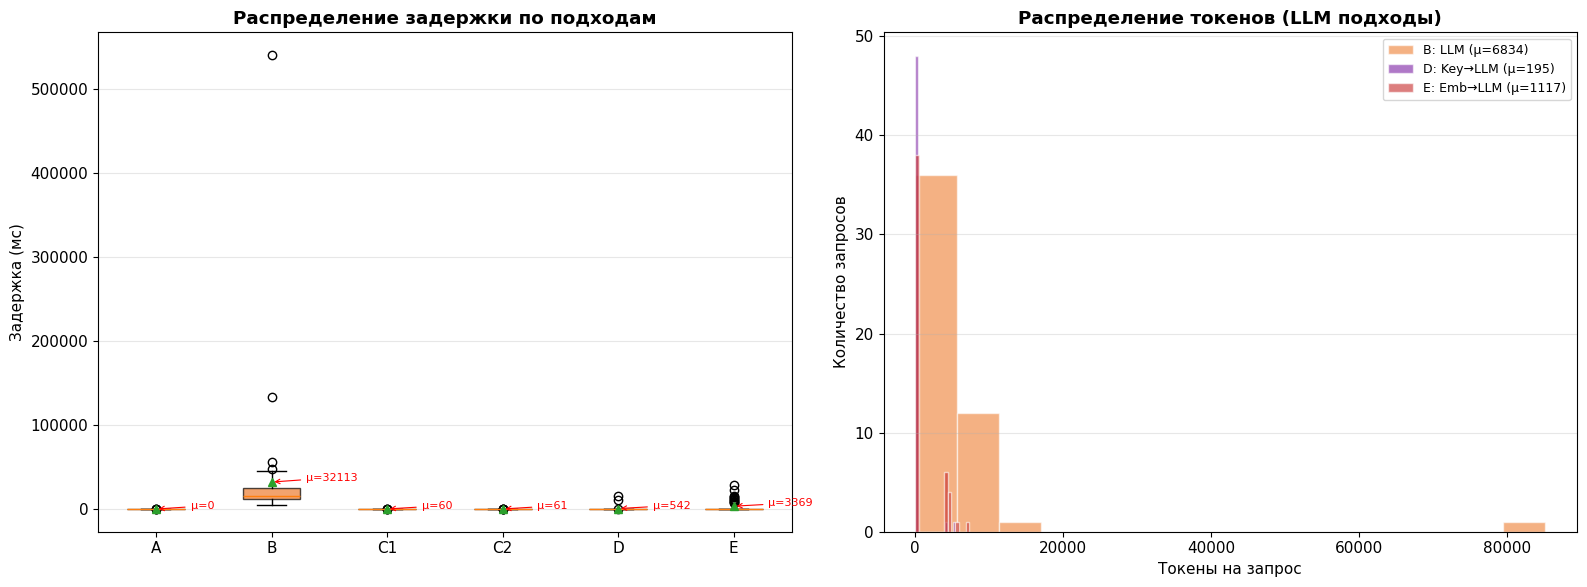

Сохранено: outputs/figures/d4_latency_and_tokens.png


In [21]:
# ============================================================================
# 7.4 Boxplot задержки по подходам (6 подходов)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7.4a Boxplot задержки
latency_data = [
    df_eval[df_eval["подход"] == a]["задержка_мс"].values for a in APPROACH_NAMES
]
# Короткие метки для оси X
short_labels = ["A", "B", "C1", "C2", "D", "E"]
bp = axes[0].boxplot(latency_data, labels=short_labels, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], APPROACH_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel("Задержка (мс)")
axes[0].set_title("Распределение задержки по подходам", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Аннотация средних
for i, a in enumerate(APPROACH_NAMES):
    mean_val = df_eval[df_eval["подход"] == a]["задержка_мс"].mean()
    axes[0].annotate(
        f"μ={mean_val:.0f}",
        xy=(i + 1, mean_val), xytext=(i + 1.3, mean_val * 1.05),
        fontsize=8, color="red",
        arrowprops=dict(arrowstyle="->", color="red", lw=0.8),
    )

# 7.4b Распределение токенов (подходы с LLM: B, D, E)
llm_approaches = ["B: LLM", "D: Key→LLM", "E: Emb→LLM"]
token_data_all = []
token_labels = []
token_colors = []
for a in llm_approaches:
    td = df_eval[df_eval["подход"] == a]["токены"]
    if td.sum() > 0:
        token_data_all.append(td.values)
        token_labels.append(a)
        idx = APPROACH_NAMES.index(a)
        token_colors.append(APPROACH_COLORS[idx])

if token_data_all:
    for j, (td, lbl, clr) in enumerate(zip(token_data_all, token_labels, token_colors)):
        axes[1].hist(td, bins=15, alpha=0.6, color=clr, edgecolor="white", label=f"{lbl} (μ={np.mean(td):.0f})")
    axes[1].set_xlabel("Токены на запрос")
    axes[1].set_ylabel("Количество запросов")
    axes[1].set_title("Распределение токенов (LLM подходы)", fontweight="bold")
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="y", alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "LLM не запускался\n(нет API ключа)", ha="center", va="center",
                 fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title("Распределение токенов (LLM подходы)", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "d4_latency_and_tokens.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: outputs/figures/d4_latency_and_tokens.png")

### 7.5 Тепловая карта: точность по подкатегориям

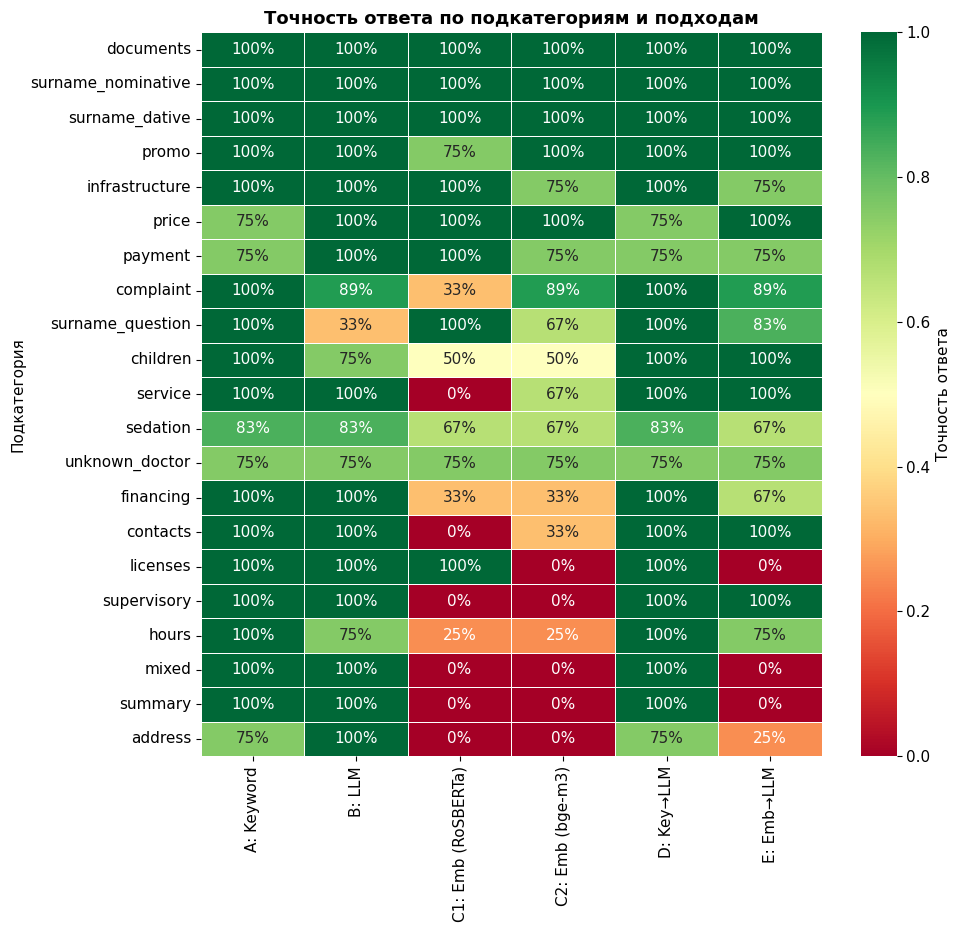

Сохранено: outputs/figures/d4_heatmap_subcategory.png


In [22]:
# ============================================================================
# 7.5 Тепловая карта: точность ответа по подкатегориям × подход
# ============================================================================

# Pivot: подкатегория × подход → средняя точность ответа
pivot = df_eval.pivot_table(
    index="подкатегория", columns="подход", values="точность_ответа", aggfunc="mean"
)
# Сортировка по средней точности
pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns="_mean")

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45)))
sns.heatmap(
    pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Точность ответа"},
)
ax.set_title("Точность ответа по подкатегориям и подходам", fontsize=13, fontweight="bold")
ax.set_ylabel("Подкатегория")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "d4_heatmap_subcategory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: outputs/figures/d4_heatmap_subcategory.png")

## 8. Анализ ошибок

Детальный разбор: какие запросы каждый подход НЕ смог обработать.

In [23]:
# ============================================================================
# 8. АНАЛИЗ ОШИБОК
# ============================================================================

def show_errors(df: pd.DataFrame, approach: str, metric_col: str, label: str) -> pd.DataFrame:
    """Показать запросы где подход ошибся по заданной метрике."""
    sub = df[(df["подход"] == approach) & (df[metric_col] == False)]
    if len(sub) == 0:
        print(f"✅ {approach}: нет ошибок по метрике «{label}»")
        return pd.DataFrame()
    print(f"\n❌ {approach}: {len(sub)} ошибок по метрике «{label}»")
    return sub[["id", "запрос", "категория", "сложность", "превью_ответа", "найден_врач", "найдена_спец"]].reset_index(drop=True)


# 8.1 Ошибки покрытия (fallback вместо содержательного ответа)
print("=" * 70)
print("8.1 ОШИБКИ ПОКРЫТИЯ (fallback вместо содержательного ответа)")
print("=" * 70)
for approach in APPROACH_NAMES:
    errors = show_errors(df_eval, approach, "покрытие", "Покрытие")
    if len(errors) > 0:
        display(errors)

8.1 ОШИБКИ ПОКРЫТИЯ (fallback вместо содержательного ответа)

❌ A: Keyword: 3 ошибок по метрике «Покрытие»


,id,запрос,категория,сложность,превью_ответа,найден_врач,найдена_спец
0,nf_1,Сколько стоит имплант?,not_found,hard,Рекомендую обратиться к специалисту: Хирургиче...,None,Хирургическая стоматология
1,nf_3,Работает ли у вас доктор Сидоров?,not_found,easy,Режим работы: ежедневно с 08:00 до 20:00,None,None
2,nf_4,Можно ли оплатить картой?,not_found,hard,"Да, доступна беспроцентная рассрочка на 6, 10 ...",None,None



❌ B: LLM: 5 ошибок по метрике «Покрытие»


,id,запрос,категория,сложность,превью_ответа,найден_врач,найдена_спец
0,ci_hours_3,Вы по выходным принимаете?,clinic_info,hard,[Ошибка: Response ended prematurely],None,None
1,ci_child_2,С какого возраста можно привести ребенка?,clinic_info,hard,В предоставленных данных нет информации о мини...,None,Детская стоматология
2,doc_name_6,Живора принимает сегодня?,doctor_search,medium,В предоставленных данных нет информации о расп...,Живора Инна Григорьевна,Ортодонтия
3,spec_gen_2,"Неприятный запах изо рта, что делать?",specialization,hard,В предоставленных данных нет информации о прич...,None,None
4,nf_3,Работает ли у вас доктор Сидоров?,not_found,easy,В предоставленных данных нет информации о докт...,None,None



❌ C1: Emb (RoSBERTa): 21 ошибок по метрике «Покрытие»


...

,id,запрос,категория,сложность,превью_ответа,найден_врач,найдена_спец
0,ci_addr_3,Как к вам приехать?,clinic_info,hard,"К сожалению, не нашёл информацию по вашему воп...",None,None
1,ci_hours_1,Во сколько вы работаете?,clinic_info,medium,"К сожалению, не нашёл информацию по вашему воп...",None,None
2,ci_hours_2,Какой у вас график?,clinic_info,easy,"К сожалению, не нашёл информацию по вашему воп...",None,None
3,ci_phone_1,Какой у вас телефон?,clinic_info,easy,"К сожалению, не нашёл информацию по вашему воп...",None,None
4,ci_phone_3,Дайте номер для записи,clinic_info,hard,"К сожалению, не нашёл информацию по вашему воп...",None,None
5,ci_fin_2,Можно заплатить частями?,clinic_info,hard,"К сожалению, не нашёл информацию по вашему воп...",None,None
6,ci_child_1,Вы принимаете детей?,clinic_info,easy,"К сожалению, не нашёл информацию по вашему воп...",None,None
7,ci_nadzor_1,Кто контролирует вашу деятельность?,clinic_info,hard,"К сожалению, не нашёл информацию по вашему воп...",None,None
8,doc_name_4,Кто такой Булатов?,doctor_search,medium,"К сожалению, не нашёл информацию по вашему воп...",None,None
9,spec_ortho_2,Хочу поставить брекеты,specialization,hard,"К сожалению, не нашёл информацию по вашему воп...",None,None



❌ D: Key→LLM: 3 ошибок по метрике «Покрытие»


,id,запрос,категория,сложность,превью_ответа,найден_врач,найдена_спец
0,nf_1,Сколько стоит имплант?,not_found,hard,Рекомендую обратиться к специалисту: Хирургиче...,None,Хирургическая стоматология
1,nf_3,Работает ли у вас доктор Сидоров?,not_found,easy,Режим работы: ежедневно с 08:00 до 20:00,None,None
2,nf_4,Можно ли оплатить картой?,not_found,hard,"Да, доступна беспроцентная рассрочка на 6, 10 ...",None,None



❌ E: Emb→LLM: 3 ошибок по метрике «Покрытие»


,id,запрос,категория,сложность,превью_ответа,найден_врач,найдена_спец
0,nf_3,Работает ли у вас доктор Сидоров?,not_found,easy,Рекомендуем: Лисин Валерий Константинович (Хир...,None,Хирургическая стоматология
1,nf_4,Можно ли оплатить картой?,not_found,hard,"Доступна беспроцентная рассрочка на 6, 10 меся...",None,None
2,nf_5,Есть ли парковка?,not_found,hard,Рекомендуем: Лисин Валерий Константинович (Хир...,None,Хирургическая стоматология


In [24]:
# 8.2 Ошибки по врачам (врач не найден или найден неправильный)
print("=" * 70)
print("8.2 ОШИБКИ ОПРЕДЕЛЕНИЯ ВРАЧА")
print("=" * 70)

# Фильтруем только запросы где ожидается врач
doc_sample_ids = [s["id"] for s in samples if s.get("expected_doctor")]
for approach in APPROACH_NAMES:
    sub = df_eval[(df_eval["подход"] == approach) & (df_eval["id"].isin(doc_sample_ids))]
    errors = sub[sub["врач_совпал"] == False]
    if len(errors) == 0:
        print(f"✅ {approach}: все врачи определены верно ({len(sub)} запросов)")
    else:
        print(f"\n❌ {approach}: {len(errors)}/{len(sub)} ошибок определения врача")
        display(errors[["id", "запрос", "найден_врач", "превью_ответа"]].reset_index(drop=True))

8.2 ОШИБКИ ОПРЕДЕЛЕНИЯ ВРАЧА
✅ A: Keyword: все врачи определены верно (9 запросов)
✅ B: LLM: все врачи определены верно (9 запросов)

❌ C1: Emb (RoSBERTa): 1/9 ошибок определения врача


,id,запрос,найден_врач,превью_ответа
0,doc_name_1,Хочу записаться к Батылину,None,Рекомендуем: Батылин Александр Александрович (...



❌ C2: Emb (bge-m3): 2/9 ошибок определения врача


,id,запрос,найден_врач,превью_ответа
0,doc_name_1,Хочу записаться к Батылину,None,Рекомендуем: Батылин Александр Александрович (...
1,doc_name_4,Кто такой Булатов?,None,"К сожалению, не нашёл информацию по вашему воп..."


✅ D: Key→LLM: все врачи определены верно (9 запросов)

❌ E: Emb→LLM: 1/9 ошибок определения врача


,id,запрос,найден_врач,превью_ответа
0,doc_name_1,Хочу записаться к Батылину,None,Рекомендуем: Батылин Александр Александрович (...


In [25]:
# 8.3 Ошибки определения специализации
print("=" * 70)
print("8.3 ОШИБКИ ОПРЕДЕЛЕНИЯ СПЕЦИАЛИЗАЦИИ")
print("=" * 70)

spec_sample_ids = [s["id"] for s in samples if s.get("expected_specialization")]
for approach in APPROACH_NAMES:
    sub = df_eval[(df_eval["подход"] == approach) & (df_eval["id"].isin(spec_sample_ids))]
    errors = sub[sub["спец_совпала"] == False]
    if len(errors) == 0:
        print(f"✅ {approach}: все специализации определены верно ({len(sub)} запросов)")
    else:
        print(f"\n❌ {approach}: {len(errors)}/{len(sub)} ошибок определения специализации")
        # Добавим ожидаемую специализацию для сравнения
        expected_specs = {s["id"]: s["expected_specialization"] for s in samples if s.get("expected_specialization")}
        err_display = errors[["id", "запрос", "найдена_спец", "превью_ответа"]].copy()
        err_display["ожидалась"] = err_display["id"].map(expected_specs)
        display(err_display.reset_index(drop=True))

8.3 ОШИБКИ ОПРЕДЕЛЕНИЯ СПЕЦИАЛИЗАЦИИ

❌ A: Keyword: 1/22 ошибок определения специализации


,id,запрос,найдена_спец,превью_ответа,ожидалась
0,mix_1,"У ребёнка шатается молочный зуб, это нормально...",Хирургическая стоматология,"Да, мы принимаем детей! Семейная клиника «Клев...",Детская стоматология



❌ B: LLM: 1/22 ошибок определения специализации


,id,запрос,найдена_спец,превью_ответа,ожидалась
0,spec_gen_2,"Неприятный запах изо рта, что делать?",None,В предоставленных данных нет информации о прич...,Терапевтическая стоматология



❌ C1: Emb (RoSBERTa): 12/22 ошибок определения специализации


...

,id,запрос,найдена_спец,превью_ответа,ожидалась
0,doc_name_4,Кто такой Булатов?,None,"К сожалению, не нашёл информацию по вашему воп...",Ортопедическая стоматология
1,spec_surg_2,Хочу поставить имплант,Терапевтическая стоматология,Рекомендуем: Абраамян Андела Корюновна (Терапе...,Хирургическая стоматология
2,spec_ther_1,Откололся кусочек зуба,Хирургическая стоматология,Рекомендуем: Никифоров Дмитрий Олегович (Хирур...,Терапевтическая стоматология
3,spec_ortho_2,Хочу поставить брекеты,None,"К сожалению, не нашёл информацию по вашему воп...",Ортодонтия
4,spec_child_1,У ребенка болит зуб,Терапевтическая стоматология,Рекомендуем: Абраамян Андела Корюновна (Терапе...,Детская стоматология
5,mix_1,"У ребёнка шатается молочный зуб, это нормально...",Хирургическая стоматология,Рекомендуем: Никифоров Дмитрий Олегович (Хирур...,Детская стоматология



❌ D: Key→LLM: 1/22 ошибок определения специализации


,id,запрос,найдена_спец,превью_ответа,ожидалась
0,mix_1,"У ребёнка шатается молочный зуб, это нормально...",Хирургическая стоматология,"Да, мы принимаем детей! Семейная клиника «Клев...",Детская стоматология



❌ E: Emb→LLM: 4/22 ошибок определения специализации


,id,запрос,найдена_спец,превью_ответа,ожидалась
0,spec_surg_2,Хочу поставить имплант,Терапевтическая стоматология,Рекомендуем: Абраамян Андела Корюновна (Терапе...,Хирургическая стоматология
1,spec_ther_1,Откололся кусочек зуба,Хирургическая стоматология,Рекомендуем: Никифоров Дмитрий Олегович (Хирур...,Терапевтическая стоматология
2,spec_child_1,У ребенка болит зуб,Терапевтическая стоматология,Рекомендуем: Абраамян Андела Корюновна (Терапе...,Детская стоматология
3,mix_1,"У ребёнка шатается молочный зуб, это нормально...",Хирургическая стоматология,Рекомендуем: Никифоров Дмитрий Олегович (Хирур...,Детская стоматология


## 9. Экономика: оценка стоимости на объёме клиники

Клевер: ~400-450 первичных/мес. Допустим ~30% из них задают FAQ → ~120-135 FAQ запросов/мес.

In [26]:
# ============================================================================
# 9. ЭКОНОМИКА (6 подходов)
# ============================================================================

FAQ_QUERIES_PER_MONTH = 130  # ~30% от 450 первичных

# Стоимость за 1K токенов (OpenRouter, qwen/qwen3.5-35b-a3b)
COST_PER_1K_INPUT = 0.00059   # $0.59 / 1M input tokens
COST_PER_1K_OUTPUT = 0.00079  # $0.79 / 1M output tokens

# Средние токены из эксперимента (подход B — все через LLM)
if HAS_LLM and any(r.tokens_used > 0 for r in results_b):
    avg_tokens_b = np.mean([r.tokens_used for r in results_b if r.tokens_used > 0])
else:
    avg_tokens_b = system_tokens_est + 100

# Fallback rate для D (keyword → LLM): доля запросов, ушедших в LLM
fallback_rate_a = sum(r.is_fallback for r in results_a) / len(results_a)

# Fallback rate для E (embedding → LLM): доля запросов, ушедших в LLM
fallback_rate_c2 = sum(r.is_fallback for r in results_c2) / len(results_c2)

# Грубая оценка: ~80% input, ~20% output
def calc_cost(avg_tokens: float) -> float:
    return (avg_tokens * 0.8 / 1000 * COST_PER_1K_INPUT +
            avg_tokens * 0.2 / 1000 * COST_PER_1K_OUTPUT)

# Эффективные токены: учитываем что первый слой обрабатывает часть запросов бесплатно
effective_tokens_d = avg_tokens_b * fallback_rate_a   # D: keyword обработал часть
effective_tokens_e = avg_tokens_b * fallback_rate_c2  # E: embedding обработал часть

cost_b = calc_cost(avg_tokens_b)
cost_d = calc_cost(effective_tokens_d)
cost_e = calc_cost(effective_tokens_e)

# Таблица экономики
econ_rows = []
for label, tokens, cost in [
    ("A: Keyword", 0, 0),
    ("B: LLM", avg_tokens_b, cost_b),
    ("C1: Emb (RoSBERTa)", 0, 0),
    ("C2: Emb (bge-m3)", 0, 0),
    ("D: Key→LLM", effective_tokens_d, cost_d),
    ("E: Emb→LLM", effective_tokens_e, cost_e),
]:
    econ_rows.append({
        "Подход": label,
        "Токенов/запрос": f"{tokens:.0f}" if tokens > 0 else "0",
        "$/запрос": f"${cost:.4f}" if cost > 0 else "$0",
        "$/мес": f"${cost * FAQ_QUERIES_PER_MONTH:.2f}" if cost > 0 else "$0",
        "$/год": f"${cost * FAQ_QUERIES_PER_MONTH * 12:.2f}" if cost > 0 else "$0",
        "Внешняя зависимость": "OpenRouter" if "LLM" in label else "Нет (локально)",
    })

economics = pd.DataFrame(econ_rows)

print("=" * 70)
print(f"ЭКОНОМИКА: оценка для клиники Клевер (~{FAQ_QUERIES_PER_MONTH} FAQ/мес)")
print(f"  Fallback rate Keyword (→D): {fallback_rate_a:.1%}")
print(f"  Fallback rate Embedding (→E): {fallback_rate_c2:.1%}")
print("=" * 70)
display(economics.set_index("Подход"))

ЭКОНОМИКА: оценка для клиники Клевер (~130 FAQ/мес)
  Fallback rate Keyword (→D): 4.0%
  Fallback rate Embedding (→E): 24.0%


,Токенов/запрос,$/запрос,$/мес,$/год,Внешняя зависимость
Подход,,,,,
A: Keyword,0,$0,$0,$0,Нет (локально)
B: LLM,6973,$0.0044,$0.57,$6.85,OpenRouter
C1: Emb (RoSBERTa),0,$0,$0,$0,Нет (локально)
C2: Emb (bge-m3),0,$0,$0,$0,Нет (локально)
D: Key→LLM,279,$0.0002,$0.02,$0.27,OpenRouter
E: Emb→LLM,1674,$0.0011,$0.14,$1.64,OpenRouter


## 10. Выводы и рекомендации

In [27]:
# ============================================================================
# 10. ВЫВОДЫ — автоматическая генерация на основе метрик (6 подходов)
# ============================================================================

def generate_conclusions(df: pd.DataFrame, samples: list) -> str:
    """Сформировать текстовые выводы на основе метрик для 6 подходов."""
    lines = []
    
    # Извлечь числовые метрики для всех подходов
    metrics = {}
    doc_ids = [s["id"] for s in samples if s.get("expected_doctor")]
    spec_ids = [s["id"] for s in samples if s.get("expected_specialization")]
    
    for approach in APPROACH_NAMES:
        sub = df[df["подход"] == approach]
        metrics[approach] = {
            "покрытие": sub["покрытие"].mean(),
            "точность": sub["точность_ответа"].mean(),
            "врач": sub[sub["id"].isin(doc_ids)]["врач_совпал"].mean() if doc_ids else 0,
            "спец": sub[sub["id"].isin(spec_ids)]["спец_совпала"].mean() if spec_ids else 0,
            "запись": sub["запись_совпала"].mean(),
            "задержка": sub["задержка_мс"].mean(),
        }
    
    # Лучший подход по каждой метрике
    best = {
        "покрытие": max(APPROACH_NAMES, key=lambda a: metrics[a]["покрытие"]),
        "точность": max(APPROACH_NAMES, key=lambda a: metrics[a]["точность"]),
        "врач": max(APPROACH_NAMES, key=lambda a: metrics[a]["врач"]),
        "спец": max(APPROACH_NAMES, key=lambda a: metrics[a]["спец"]),
        "задержка": min(APPROACH_NAMES, key=lambda a: metrics[a]["задержка"]),
    }
    
    lines.append("# D4: Выводы эксперимента (v2 — 6 подходов)\n")
    
    # --- Модели ---
    lines.append("## Использованные модели\n")
    lines.append(f"- **LLM (B, D, E):** `{LLM_MODEL}` via OpenRouter (temperature={LLM_TEMPERATURE})")
    lines.append(f"- **Embedding C1:** `{ENCODER_MODEL_1}` (device={ENCODER_DEVICE})")
    lines.append(f"- **Embedding C2:** `{ENCODER_MODEL_2}` (device={ENCODER_DEVICE})")
    lines.append(f"- **Тестовый набор:** {len(samples)} golden samples")
    lines.append("")
    
    # --- Результаты по метрикам ---
    lines.append("## Результаты по метрикам\n")
    
    metric_names = [
        ("покрытие", "Покрытие (Coverage)"),
        ("точность", "Точность ответа"),
        ("врач", "Определение врача (precision)"),
        ("спец", "Определение специализации"),
    ]
    
    for key, label in metric_names:
        lines.append(f"**{label}:**")
        for a in APPROACH_NAMES:
            lines.append(f"- {a}: {metrics[a][key]:.1%}")
        lines.append(f"- Лучший: **{best[key]}** ({metrics[best[key]][key]:.1%})")
        lines.append("")
    
    # Задержка
    lines.append(f"**Задержка:**")
    for a in APPROACH_NAMES:
        lines.append(f"- {a}: {metrics[a]['задержка']:.1f} мс")
    lines.append(f"- Самый быстрый: **{best['задержка']}** ({metrics[best['задержка']]['задержка']:.1f} мс)")
    lines.append("")
    
    # --- Сравнение embedding моделей ---
    lines.append("## Сравнение embedding моделей (C1 vs C2)\n")
    c1, c2 = metrics["C1: Emb (RoSBERTa)"], metrics["C2: Emb (bge-m3)"]
    for key, label in metric_names:
        diff = c2[key] - c1[key]
        sign = "+" if diff >= 0 else ""
        lines.append(f"- {label}: C1={c1[key]:.1%}, C2={c2[key]:.1%} ({sign}{diff:.1%})")
    lines.append(f"- Задержка: C1={c1['задержка']:.1f}мс, C2={c2['задержка']:.1f}мс")
    winner_emb = "C2 (bge-m3)" if c2["покрытие"] + c2["точность"] > c1["покрытие"] + c1["точность"] else "C1 (RoSBERTa)"
    lines.append(f"- **Вывод:** {winner_emb} показывает лучшие результаты")
    lines.append("")
    
    # --- Эффективность гибридных подходов ---
    lines.append("## Эффективность гибридных подходов\n")
    a_m = metrics["A: Keyword"]
    c2_m = metrics["C2: Emb (bge-m3)"]
    d_m = metrics["D: Key→LLM"]
    e_m = metrics["E: Emb→LLM"]
    
    lines.append("**D (Keyword → LLM) vs A (Keyword):**")
    for key, label in metric_names:
        diff = d_m[key] - a_m[key]
        sign = "+" if diff >= 0 else ""
        lines.append(f"- {label}: {sign}{diff:.1%} ({a_m[key]:.1%} → {d_m[key]:.1%})")
    lines.append("")
    
    lines.append("**E (Embedding → LLM) vs C2 (Embedding bge-m3):**")
    for key, label in metric_names:
        diff = e_m[key] - c2_m[key]
        sign = "+" if diff >= 0 else ""
        lines.append(f"- {label}: {sign}{diff:.1%} ({c2_m[key]:.1%} → {e_m[key]:.1%})")
    lines.append("")
    
    # --- Weighted Score ---
    lines.append("## Рекомендация: взвешенный скор\n")
    
    LATENCY_HALF_LIFE_MS = 5000
    scores = {}
    for a in APPROACH_NAMES:
        m = metrics[a]
        quality = (m["покрытие"] + m["точность"] + m["врач"] + m["спец"]) / 4
        latency_score = 1 / (1 + m["задержка"] / LATENCY_HALF_LIFE_MS)
        # Стоимость: подходы с LLM дороже
        if a == "B: LLM":
            cost_score = 0.3  # Все запросы через LLM
        elif a == "D: Key→LLM":
            cost_score = 0.6  # Только fallback через LLM
        elif a == "E: Emb→LLM":
            cost_score = 0.5  # Embedding fallback + LLM fallback
        else:
            cost_score = 1.0  # Без LLM
        scores[a] = quality * 0.7 + latency_score * 0.15 + cost_score * 0.15
    
    best_overall = max(APPROACH_NAMES, key=lambda a: scores[a])
    lines.append(f"**Формула:** качество×0.7 + задержка×0.15 + стоимость×0.15")
    lines.append(f"  Latency: гиперболическая нормализация (half-life={LATENCY_HALF_LIFE_MS}мс)")
    lines.append(f"  Cost: B=0.3, D=0.6, E=0.5, остальные=1.0")
    lines.append("")
    for a in APPROACH_NAMES:
        marker = " ← **рекомендован**" if a == best_overall else ""
        lines.append(f"- {a}: **{scores[a]:.3f}**{marker}")
    
    return "\n".join(lines)

conclusions_text = generate_conclusions(df_eval, samples)
print(conclusions_text)

# D4: Выводы эксперимента (v2 — 6 подходов)

## Использованные модели

- **LLM (B, D, E):** `qwen/qwen3.5-35b-a3b` via OpenRouter (temperature=0.1)
- **Embedding C1:** `ai-forever/ru-en-RoSBERTa` (device=mps)
- **Embedding C2:** `BAAI/bge-m3` (device=mps)
- **Тестовый набор:** 50 golden samples

## Результаты по метрикам

**Покрытие (Coverage):**
- A: Keyword: 94.0%
- B: LLM: 90.0%
- C1: Emb (RoSBERTa): 58.0%
- C2: Emb (bge-m3): 74.0%
- D: Key→LLM: 94.0%
- E: Emb→LLM: 94.0%
- Лучший: **A: Keyword** (94.0%)

**Точность ответа:**
- A: Keyword: 95.5%
- B: LLM: 89.5%
- C1: Emb (RoSBERTa): 47.0%
- C2: Emb (bge-m3): 58.5%
- D: Key→LLM: 95.5%
- E: Emb→LLM: 77.5%
- Лучший: **A: Keyword** (95.5%)

**Определение врача (precision):**
- A: Keyword: 100.0%
- B: LLM: 100.0%
- C1: Emb (RoSBERTa): 88.9%
- C2: Emb (bge-m3): 77.8%
- D: Key→LLM: 100.0%
- E: Emb→LLM: 88.9%
- Лучший: **A: Keyword** (100.0%)

**Определение специализации:**
- A: Keyword: 95.5%
- B: LLM: 95.5%
- C1: Emb (RoSBERTa): 45.5%
- C2

## 11. Экспорт артефактов

In [ ]:
# ============================================================================
# 11. ЭКСПОРТ АРТЕФАКТОВ (6 подходов)
# ============================================================================

# 11.1 Полные результаты оценки в CSV
eval_csv_path = OUTPUT_DIR / "tables" / "d4_eval_results.csv"
eval_csv_path.parent.mkdir(parents=True, exist_ok=True)
df_eval.to_csv(eval_csv_path, index=False, encoding="utf-8-sig")
print(f"Результаты оценки: {eval_csv_path}")

# 11.2 Сводная таблица метрик
summary_csv_path = OUTPUT_DIR / "tables" / "d4_metrics_summary.csv"
metrics_summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")
print(f"Сводка метрик: {summary_csv_path}")

# 11.3 Отчёт в Markdown (с трекингом моделей)
report_path = OUTPUT_DIR / "reports" / "D4_FAQ_SEARCH_COMPARISON.md"
report_path.parent.mkdir(parents=True, exist_ok=True)

report_lines = [
    "# D4: Сравнение подходов FAQ Search (v2 — 6 подходов)",
    "",
    f"**Дата:** {time.strftime('%Y-%m-%d %H:%M')}",
    f"**Тестовый набор:** {len(samples)} golden samples",
    "",
    "## Модели",
    "",
    "| Компонент | Модель | Параметры |",
    "|-----------|--------|-----------|",
    f"| LLM (B, D, E) | `{LLM_MODEL}` | temperature={LLM_TEMPERATURE}, via OpenRouter |",
    f"| Embedding C1 | `{ENCODER_MODEL_1}` | device={ENCODER_DEVICE} |",
    f"| Embedding C2 | `{ENCODER_MODEL_2}` | device={ENCODER_DEVICE} |",
    "",
    "**Подходы:**",
    "- A: Keyword (воспроизведение kb_stub.py + specialists.py)",
    "- B: LLM (context stuffing → OpenRouter)",
    f"- C1: Embedding ({ENCODER_MODEL_1})",
    f"- C2: Embedding ({ENCODER_MODEL_2})",
    "- D: Keyword → LLM (hybrid, fallback на B)",
    "- E: Embedding (bge-m3) → LLM (hybrid, fallback на B)",
    "",
    "---",
    "",
    "## Сводная таблица",
    "",
    metrics_summary.to_markdown(index=False),
    "",
    "---",
    "",
    conclusions_text,
    "",
    "---",
    "",
    "## Методология оценки",
    "",
    "- **Coverage**: корректное поведение (ответ для answerable запросов, fallback для not_found)",
    "- **Answer accuracy**: доля ожидаемых ключевых фраз в ответе",
    "- **Weighted score**: quality×0.7 + latency×0.15 + cost×0.15",
    "  - Latency: гиперболическая нормализация (half-life=5000мс)",
    "  - Cost: B=0.3, D=0.6, E=0.5, остальные=1.0",
    "",
    "## Артефакты",
    "",
    f"- Результаты: `{eval_csv_path.relative_to(STUDY_ROOT)}`",
    f"- Сводка: `{summary_csv_path.relative_to(STUDY_ROOT)}`",
    "- Графики:",
    "  - `outputs/figures/d4_metrics_comparison.png`",
    "  - `outputs/figures/d4_coverage_by_category.png`",
    "  - `outputs/figures/d4_accuracy_by_difficulty.png`",
    "  - `outputs/figures/d4_latency_and_tokens.png`",
    "  - `outputs/figures/d4_heatmap_subcategory.png`",
]

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"Отчёт: {report_path}")

# 11.4 JSON с числовыми метриками
results_json_path = OUTPUT_DIR / "d4_results.json"
numeric_metrics = {}
for approach in APPROACH_NAMES:
    sub = df_eval[df_eval["подход"] == approach]
    doc_ids = [s["id"] for s in samples if s.get("expected_doctor")]
    spec_ids = [s["id"] for s in samples if s.get("expected_specialization")]
    
    numeric_metrics[approach] = {
        "покрытие": round(float(sub["покрытие"].mean()), 4),
        "точность_ответа": round(float(sub["точность_ответа"].mean()), 4),
        "врач_precision": round(float(sub[sub["id"].isin(doc_ids)]["врач_совпал"].mean()), 4) if doc_ids else None,
        "специализация": round(float(sub[sub["id"].isin(spec_ids)]["спец_совпала"].mean()), 4) if spec_ids else None,
        "предложение_записи": round(float(sub["запись_совпала"].mean()), 4),
        "задержка_мс_средняя": round(float(sub["задержка_мс"].mean()), 2),
        "токены_средние": round(float(sub["токены"].mean()), 0) if sub["токены"].sum() > 0 else 0,
    }

with open(results_json_path, "w", encoding="utf-8") as f:
    json.dump({
        "experiment": "D4_faq_search_comparison_v2",
        "version": 2,
        "date": time.strftime("%Y-%m-%d"),
        "n_samples": len(samples),
        "n_approaches": len(APPROACH_NAMES),
        "approaches": APPROACH_NAMES,
        "models": {
            "llm": LLM_MODEL,
            "llm_temperature": LLM_TEMPERATURE,
            "llm_provider": "OpenRouter",
            "encoder_c1": ENCODER_MODEL_1,
            "encoder_c2": ENCODER_MODEL_2,
            "encoder_device": ENCODER_DEVICE,
        },
        "evaluation_methodology": {
            "coverage": "correct_behavior (answer for answerable, fallback for not_found)",
            "accuracy": "keyword_phrase_matching",
            "weighted_score": "quality*0.7 + latency*0.15 + cost*0.15",
            "latency_normalization": "hyperbolic (half-life=5000ms)",
            "cost_weights": {"B: LLM": 0.3, "D: Key→LLM": 0.6, "E: Emb→LLM": 0.5, "others": 1.0},
        },
        "metrics": numeric_metrics,
    }, f, ensure_ascii=False, indent=2)
print(f"JSON метрики: {results_json_path}")

print("\n" + "=" * 70)
print("ЭКСПОРТ ЗАВЕРШЁН — 6 подходов")
print("=" * 70)

Результаты оценки: /Users/kazdoraw/developer/med-agent/study/outputs/tables/d4_eval_results.csv
Сводка метрик: /Users/kazdoraw/developer/med-agent/study/outputs/tables/d4_metrics_summary.csv
Отчёт: /Users/kazdoraw/developer/med-agent/study/outputs/reports/D4_FAQ_SEARCH_COMPARISON.md
JSON метрики: /Users/kazdoraw/developer/med-agent/study/outputs/d4_results.json

ЭКСПОРТ ЗАВЕРШЁН — 6 подходов


: 